# Librerias

In [1]:
from pandas.core.computation.check import NUMEXPR_INSTALLED
import pandas as pd
import numpy as np
import os
# from osgeo import gdal
import geopandas as gpd
import rasterio
# import math
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

# Navarra

In [21]:
os.chdir('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Incendios\\Organizacion\\Resultados')
Navarra=pd.read_csv('Navarra_NBR_011124.csv')
# Navarra=Navarra[['Row','ID','year_recovery','FECHA','Label','Slope','Height','Aspect','Magnitude','NBR_before','Especie1']]

# filtro_Nav=pd.read_csv('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Doctorado\\Datos Estancia\\Incendios_estancia\\Filtrados\\Usar_NBR\\Filter_R_Navarra_011124.csv')

# filtro_Nav=filtro_Nav[['Row']]
# Nav=pd.merge(Navarra,filtro_Nav,on='Row')

# del Navarra,filtro_Nav

In [ ]:
len(Navarra)

In [ ]:
# Nav_5=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Navarra_tasa_5.csv')
# Nav_20=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Navarra_tasa_20.csv')

Nav_5=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Navarra_tasa5_NBR_post.csv')
Nav_20=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Navarra_tasa20_NBR_post.csv')

In [ ]:
# print(Nav_5.groupby('Vez')['Vez'].count())
# print(Nav_5.loc[(Nav_5.Cambio<=0)])

In [ ]:
Nav_5=Nav_5.loc[(Nav_5.Vez==0)]
Nav_20=Nav_20.loc[(Nav_20.Vez==0)]

Nav_5=Nav_5.loc[(Nav_5.Cambio>0)]
Nav_20=Nav_20.loc[(Nav_20.Cambio>0)]

print(len(Nav_5),len(Nav_20))


In [ ]:
Nav_5.columns

In [ ]:
# Nav_5=Nav_5[['Row','Tasa']]
# Nav_5.columns=['Row','Tasa_5']
# Nav_20=Nav_20[['Row','Tasa']]
# Nav_20.columns=['Row','Tasa_20']

Nav_5['Tasa_5']=(Nav_5.NBR_5-Nav_5.NBR_post)/5
# Nav_5['Rate_5/year']=(Nav_5.NBR_5-Nav_5.NBR_post)/5

Nav_20['Tasa_20']=(Nav_20.NBR_20-Nav_20.NBR_post)/20

# Nav_20['Rate_20/year']=(Nav_20.NBR_20-Nav_20.NBR_post)/20



In [ ]:
Nav_20.loc[(Nav_20.Tasa_20<0)]

In [ ]:
Nav_5.loc[(Nav_5.Tasa_5<0)]

In [ ]:
Nav_5=Nav_5[['Row','Tasa_5']]
Nav_20=Nav_20[['Row','Tasa_20']]

In [ ]:
Nav=pd.merge(Nav,Nav_5,on='Row')
Nav=pd.merge(Nav,Nav_20,on='Row')
Nav.columns

In [ ]:
len(Nav)

In [ ]:
Nav=Nav.loc[(Nav['Tasa_5']>0)&(Nav['Tasa_20']>0)]
len(Nav)

In [ ]:
# os.chdir('C:\\Users\\agiambel.stu\\OneDrive\\Incendios\\Organizacion\\Resultados\\Clima\\Navarra')
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Incendios\Clima\5y20')

# os.chdir(r'C:\Users\laugi\OneDrive_backup\3\OneDrive\Incendios\Clima\5y20')
# os.listdir()
clima_a=pd.read_csv('Navarra_5y20.csv')
clima_a


In [ ]:
os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\SPEI\\SEPI_Nav')
# os.listdir()
spei=pd.read_csv('Navarra_spei.csv')
SPEI=pd.merge(spei,Nav,on='Row')
SPEI['Year']=SPEI['Year'].astype(int)
SPEI['FECHA']=SPEI['FECHA'].astype(int)

filtered_5year=SPEI.loc[((SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+5)))]
filtered_20year=SPEI.loc[(SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+20))]

resultados_prec_5 = filtered_5year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_5.columns=['Row','spei6_5']
resultados_prec_20 = filtered_20year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_20.columns=['Row','spei6_20']

join_spei=pd.merge(resultados_prec_5,resultados_prec_20,on='Row')

union_1=pd.merge(Nav,join_spei,on='Row')
join_nav=pd.merge(union_1,clima_a,on='Row')

del union_1,SPEI

In [ ]:
join_nav=join_nav[['Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope', 'Height',
       'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5', 'Tasa_20',
       'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20']]

In [ ]:
join_nav.to_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Navarra_Recuperando_20_30012025_cambio.csv')

In [ ]:
# NO
# os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tendencia_NBR')
# tend_nav=pd.read_csv('Navarra_tend.csv')
# tend_val=pd.read_csv('Valencia_tend.csv')
# tend_cat=pd.read_csv('Catalunia_tend.csv')

In [ ]:
# Nav=pd.merge(Nav,tend_nav, on='Row')

# Valencia

In [ ]:
# Val_5=pd.read_csv('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Incendios\\Organizacion\\Tasa\\Valencia_tasa_5.csv')
# Val_20=pd.read_csv('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Incendios\\Organizacion\\Tasa\\Valencia_tasa_20.csv')

Val_5=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Valencia_tasa5_NBR_post.csv')
Val_20=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Valencia_tasa20_NBR_post.csv')

In [ ]:
Val_5=Val_5.loc[(Val_5.Vez==0)]
Val_20=Val_20.loc[(Val_20.Vez==0)]

Val_5=Val_5.loc[(Val_5.Cambio>0)]
Val_20=Val_20.loc[(Val_20.Cambio>0)]

print(len(Val_5),len(Val_20))


In [ ]:
Val_5['Tasa_5']=(Val_5.NBR_5-Val_5.NBR_post)/5
# Val_5['Rate_5/year']=(Val_5.NBR_5-Val_5.NBR_post)/5

Val_20['Tasa_20']=(Val_20.NBR_20-Val_20.NBR_post)/20
# Val_20['Rate_20/year']=(Val_20.NBR_20-Val_20.NBR_post)/20

In [ ]:
# print(Val_20.groupby('Vez')['Vez'].count())
# Val_20=Val_20.loc[(Val_20.Cambio>0)]

In [ ]:
Val_5=Val_5[['Row','Tasa_5']]
# Val_5.columns=['Row','Tasa_5']
Val_20=Val_20[['Row','Tasa_20']]
# Val_20.columns=['Row','Tasa_20']

In [ ]:
Val_tasa=pd.merge(Val_20,Val_5,on='Row')
len(Val_tasa)

In [ ]:
Val_tasa=Val_tasa.loc[(Val_tasa.Tasa_5>0)&(Val_tasa.Tasa_20>0)]
len(Val_tasa)

In [22]:
# os.chdir('C:\\Users\\agiambel.stu\\OneDrive\\Incendios\\Organizacion\\Resultados')
# os.chdir('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Incendios\\Organizacion\\Resultados')
os.chdir('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Incendios\\Organizacion\\Resultados')
Valencia=pd.read_csv('Valencia_NBR_011124.csv')
# Valencia=Valencia[['Row','ID','year_recovery','FECHA','Label','Slope','Height','Aspect','Magnitude','NBR_before','Especie1']]

# filtro_Val=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Doctorado\\Datos Estancia\\Incendios_estancia\\Filtrados\\Usar_NBR\\Filter_R_Valencia_011124.csv')

# filtro_Val=filtro_Val[['Row']]
# Val=pd.merge(Valencia,filtro_Val,on='Row')

# del Valencia,filtro_Val

In [ ]:
Val=pd.merge(Val,Val_tasa,on='Row')
len(Val)

In [ ]:
len(filtro_Val)

In [ ]:
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Incendios\Clima\5y20')
# os.chdir(r'C:\Users\laugi\OneDrive_backup\3\OneDrive\Incendios\Clima\5y20')
os.listdir()

In [ ]:
prec=pd.read_csv('Valencia_prec_5y20.csv')
prec.Prec_20.min()

In [ ]:

tmax=pd.read_csv('Valencia_tmax_5y20.csv')
tmin=pd.read_csv('Valencia_tmin_5y20.csv')
os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\SPEI\\SEPI_Val')

spei=pd.read_csv('Valencia_spei.csv')
SPEI=pd.merge(spei,Val,on='Row')
SPEI['Year']=SPEI['Year'].astype(int)
SPEI['FECHA']=SPEI['FECHA'].astype(int)

filtered_5year=SPEI.loc[((SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+5)))]
filtered_20year=SPEI.loc[(SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+20))]

resultados_prec_5 = filtered_5year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_5.columns=['Row','spei6_5']
resultados_prec_20 = filtered_20year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_20.columns=['Row','spei6_20']

join_spei=pd.merge(resultados_prec_5,resultados_prec_20,on='Row')

union_1=pd.merge(Val,join_spei,on='Row')
union_2=pd.merge(union_1,prec,on='Row')
union_2=pd.merge(union_2,tmin,on='Row')
join_val=pd.merge(union_2,tmax,on='Row')


In [ ]:
join_val.columns

In [ ]:
join_val=join_val[['Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope', 'Height',
       'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5', 'Tasa_20',
       'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20']]

In [ ]:
join_val.to_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Valencia_Recuperando_20_30012025_cambio.csv')

# Catalunia

In [23]:
# os.chdir('C:\\Users\\agiambel.stu\\OneDrive\\Incendios\\Organizacion\\Resultados')
os.chdir('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Incendios\\Organizacion\\Resultados')
Catalunia=pd.read_csv('Catalunia_NBR_011124.csv')
# Catalunia=Catalunia[['Row','ID','year_recovery','FECHA','Label','Slope','Height','Aspect','Magnitude','NBR_before','Especie1']]

# filtro_Cat=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Doctorado\\Datos Estancia\\Incendios_estancia\\Filtrados\\Usar_NBR\\Filter_R_Catalunia_011124.csv')

# filtro_Cat=filtro_Cat[['Row']]
# Cat=pd.merge(Catalunia,filtro_Cat,on='Row')

# del Catalunia,filtro_Cat

In [ ]:
# Cat_5=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Catalunia_tasa_5.csv')
# Cat_20=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Catalunia_tasa_20.csv')

Cat_5=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Catalunia_tasa5_NBR_post.csv')
Cat_20=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa\\Catalunia_tasa20_NBR_post.csv')

In [ ]:
Cat_5=Cat_5.loc[(Cat_5.Vez==0)]
Cat_20=Cat_20.loc[(Cat_20.Vez==0)]

Cat_5=Cat_5.loc[(Cat_5.Cambio>0)]
Cat_20=Cat_20.loc[(Cat_20.Cambio>0)]

print(len(Cat_5),len(Cat_20))


In [ ]:
Cat_5['Tasa_5']=(Cat_5.NBR_5-Cat_5.NBR_post)/5
# Cat_5['Rate_5/year']=(Cat_5.NBR_5-Cat_5.NBR_post)/5

Cat_20['Tasa_20']=(Cat_20.NBR_20-Cat_20.NBR_post)/20
# Cat_20['Rate_20/year']=(Cat_20.NBR_20-Cat_20.NBR_post)/20

In [ ]:
Cat_5=Cat_5[['Row','Tasa_5']]
# Cat_5.columns=['Row','Tasa_5']
Cat_20=Cat_20[['Row','Tasa_20']]
# Cat_20.columns=['Row','Tasa_20']

In [ ]:
Cat_tasa=pd.merge(Cat_20,Cat_5,on='Row')
len(Cat_tasa)

In [ ]:
Cat_tasa=Cat_tasa.loc[(Cat_tasa.Tasa_5>0)&(Cat_tasa.Tasa_20>0)]
len(Val_tasa)

In [ ]:
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Incendios\Clima\5y20')
# os.listdir()
# os.chdir(r'C:\Users\laugi\OneDrive_backup\3\OneDrive\Incendios\Clima\5y20')

In [ ]:
prec=pd.read_csv('Catalunia_prec_5y20.csv')
prec.Prec_5.min()

In [ ]:

tmax=pd.read_csv('Catalunia_tmax_5y20.csv')
tmin=pd.read_csv('Catalunia_tmin_5y20.csv')

os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\SPEI\\SEPI_Cat')

spei=pd.read_csv('Catalunia_spei.csv')
SPEI=pd.merge(spei,Cat,on='Row')
SPEI['Year']=SPEI['Year'].astype(int)
SPEI['FECHA']=SPEI['FECHA'].astype(int)

filtered_5year=SPEI.loc[((SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+5)))]
filtered_20year=SPEI.loc[(SPEI.Year>=SPEI.FECHA)&(SPEI.Year<(SPEI.FECHA+20))]

resultados_prec_5 = filtered_5year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_5.columns=['Row','spei6_5']
resultados_prec_20 = filtered_20year.groupby('Row')['spei6'].mean().reset_index()
resultados_prec_20.columns=['Row','spei6_20']

join_spei=pd.merge(resultados_prec_5,resultados_prec_20,on='Row')


union_1=pd.merge(Cat,join_spei,on='Row')
union_1=pd.merge(union_1,Cat_tasa,on='Row')
union_2=pd.merge(union_1,prec,on='Row')
union_2=pd.merge(union_2,tmin,on='Row')
join_cat=pd.merge(union_2,tmax,on='Row')


In [ ]:
join_cat.columns

In [ ]:
join_cat=join_cat[['Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope', 'Height',
       'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5', 'Tasa_20',
       'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20']]

In [ ]:
len(join_cat)

In [ ]:
join_cat.to_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Catalunia_Recuperando_20_30012025_cambio.csv')

# Union datos

In [16]:
# join_nav=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Navarra_STCSPEITASA5_20_27012025.csv')
# join_cat=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Catalunia_STCSPEITASA5_20_27012025.csv')
# join_val=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Valencia_STCSPEITASA5_20_27012025.csv')

join_nav=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Tasa_post_normalizado_30012025\\Navarra_Recuperando_20_30012025_cambio.csv')
join_cat=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Tasa_post_normalizado_30012025\\Catalunia_Recuperando_20_30012025_cambio.csv')
join_val=pd.read_csv('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Resultados\\Unido_Tasa5y20\\Tasa_post_normalizado_30012025\\Valencia_Recuperando_20_30012025_cambio.csv')


In [17]:
join=pd.concat([join_nav,join_cat,join_val])
len(join)

27856

In [22]:
join.groupby('FECHA')['Row'].count()

FECHA
1986     5551
1987      193
1988      100
1989     1042
1990      131
1991      452
1992       41
1993      880
1994    13926
1995      742
1996       68
1997       74
1998     2426
1999      213
2000      372
2001      218
2002      124
2003     1303
Name: Row, dtype: int64

In [4]:
join=join.dropna()
len(join)

27845

In [5]:
join=join.loc[(join.NBR_before<1)]

In [6]:
join.loc[(join.year_recovery==99999)]

,Unnamed: 0,Row,ID,year_recovery,FECHA,Label,Slope,Height,Aspect,Magnitude,...,Tasa_5,Tasa_20,spei6_5,spei6_20,Prec_5,Prec_20,Tmin_5,Tmin_20,Tmax_5,Tmax_20
222,222,[4296 5535],382_N,99999,1991,Pinus,18.186075,757.0,306.24994,-0.535657,...,0.010081,0.011906,-0.136475,-0.289718,1726.600036,7034.900127,10.958983,11.286854,22.214903,22.526437
228,228,[4301 5535],382_N,99999,1991,Pinus,20.849419,763.0,260.21120,-0.512272,...,0.006257,0.007141,-0.136475,-0.289718,1726.600036,7034.900127,10.958983,11.286854,22.214903,22.526437
237,237,[4309 5542],382_N,99999,1991,Pinus,6.830702,727.0,132.50806,-0.322459,...,0.005466,0.005221,-0.136475,-0.289718,1726.600036,7034.900127,10.958983,11.286854,22.214903,22.526437
286,286,[5731 7058],394_N,99999,1994,Pinus,13.429320,798.0,227.31616,-0.616781,...,0.007471,0.005735,-0.505469,-0.321065,1311.200027,6818.400172,10.729058,10.975057,23.136512,23.088658
291,291,[5737 7054],394_N,99999,1994,Pinus,11.494039,753.0,256.18290,-0.630907,...,0.070005,0.010056,-0.505469,-0.321065,1311.200027,6818.400172,10.729058,10.975057,23.136512,23.088658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5869,5869,[4126 6151],2258_V,99999,1994,Quercus,15.798788,680.0,304.89750,-0.841192,...,0.002470,0.002961,-0.563916,-0.571818,777.900016,3923.900060,14.651483,15.137436,25.749462,26.055704
5870,5870,[4129 6160],2258_V,99999,1994,Quercus,29.018414,795.0,294.11313,-0.268508,...,0.000097,0.000059,-0.563916,-0.571818,777.900016,3923.900060,14.651483,15.137436,25.749462,26.055704
5913,5913,[1335 6060],10655_V,99999,1994,Quercus,3.900092,989.0,341.76492,-0.404693,...,0.005027,0.005832,-0.471289,-0.303296,979.900025,4506.900111,10.728532,11.133698,23.978679,24.265632
5921,5921,[2977 6375],2200_V,99999,1994,Quercus,33.268013,704.0,284.28440,-0.413047,...,0.002321,0.002978,-0.514225,-0.394548,860.100009,4101.800057,13.624314,14.136307,25.365201,25.667867


In [23]:
join.Rate_5.hist()

AttributeError: 'DataFrame' object has no attribute 'Rate_5'

In [6]:
join=join.loc[join.Magnitude>-1.5]
len(join)

27738

In [9]:
join

,Unnamed: 0,Row,ID,year_recovery,FECHA,Label,Slope,Height,Aspect,Magnitude,...,Tasa_5,Tasa_20,spei6_5,spei6_20,Prec_5,Prec_20,Tmin_5,Tmin_20,Tmax_5,Tmax_20
0,0,[4814 4357],369_N,1996,1989,Pinus,38.204690,405.0,149.750050,-0.298346,...,0.027816,0.019509,-0.125195,-0.373267,1611.200033,6057.100109,10.861633,11.363006,22.938018,23.348607
1,1,[4817 4354],369_N,1991,1989,Pinus,34.709350,381.0,163.369110,-0.178066,...,0.021691,0.012786,-0.125195,-0.373267,1611.200033,6057.100109,10.861633,11.363006,22.938018,23.348607
2,2,[4844 4384],369_N,1997,1989,Pinus,23.655857,385.0,252.804520,-0.453630,...,0.027924,0.006805,-0.125195,-0.373267,1414.800032,5436.500088,11.900427,12.393992,24.381888,24.833597
3,3,[2842 4948],305_N,1996,1989,Pinus,5.689922,257.0,347.114650,-0.362026,...,0.021257,0.025155,-0.271419,-0.373995,3005.700048,11650.500236,13.225489,13.454931,21.780928,22.156731
4,4,[2846 4949],305_N,1995,1989,Pinus,40.257263,245.0,85.614456,-0.362478,...,0.018845,0.024339,-0.271419,-0.373995,3005.700048,11650.500236,13.225489,13.454931,21.780928,22.156731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5954,5954,[3408 5847],2245_V,1995,1994,Pinus,11.701507,731.0,149.286480,-0.153626,...,0.005958,0.007218,-0.539372,-0.471273,845.400014,3941.100051,13.192182,13.646312,25.467111,25.823026
5955,5955,[3128 6101],2200_V,2004,1994,Pinus,7.344077,985.0,221.097530,-0.243731,...,0.009919,0.011626,-0.514225,-0.394548,954.400037,4292.200074,12.031904,12.488835,24.454962,24.779507
5956,5956,[2373 8052],10664_V,1998,1994,Pinus,11.993736,465.0,90.000000,-0.134312,...,0.012347,0.014921,-0.545947,-0.475777,776.600009,3965.800052,15.590488,16.155933,26.428979,26.536334
5957,5957,[1158 6523],10655_V,2007,1994,Quercus,2.220842,1059.0,213.400570,-0.217890,...,0.003789,0.004169,-0.483512,-0.278682,910.100018,4362.800093,11.503016,11.888057,24.426156,24.694758


In [ ]:
#Codigo para exportar los incendios definitivos

# Navarra=Navarra[['Row','longitude','latitude']]
# Valencia=Valencia[['Row','longitude','latitude']]
# Catalunia=Catalunia[['Row','longitude','latitude']]



1021205

In [ ]:
# ptos_Nav=pd.merge(join,Navarra,on='Row')
# ptos_Val=pd.merge(join,Valencia,on='Row')
# ptos_Cat=pd.merge(join,Catalunia,on='Row')

# mer=pd.concat([ptos_Nav,ptos_Val,ptos_Cat])
# len(mer)

27464

In [ ]:
# len(ptos_Nav)

876

In [ ]:
# mer.to_csv('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Doctorado\\Articulos\\Wildfire\\Puntos\\ptos_NBR_13022025.csv')
# len(mer)

27464

# Random Forest Regresión

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
import numpy as np
from sklearn import metrics, model_selection

In [8]:
join['year_recovery']=join['year_recovery'].astype(int)
join['FECHA']=join['FECHA'].astype(int)
join['Y2R_NBR']=join['year_recovery']-join['FECHA']

In [9]:
join=join.loc[(join.Y2R_NBR!=0)]
len(join)

27387

In [10]:
join_r=join.loc[join.year_recovery!=99999]
len(join)-len(join_r)

1880

In [15]:
join[['Row','ID','NBR_before']]

,Row,ID,NBR_before
0,[4814 4357],369_N,0.436012
1,[4817 4354],369_N,0.444558
2,[4844 4384],369_N,0.664941
3,[2842 4948],305_N,0.794610
4,[2846 4949],305_N,0.739169
...,...,...,...
5954,[3408 5847],2245_V,0.339665
5955,[3128 6101],2200_V,0.178274
5956,[2373 8052],10664_V,0.352999
5957,[1158 6523],10655_V,0.258917


In [12]:
len(list(set(join.ID)))

558

In [14]:
join_r=join

In [14]:
join_r.groupby('ID')['ID'].count()

ID
100_N        8
101_C        1
10655_V    327
10656_V      3
10662_V      2
          ... 
95_C         7
96_C        13
97_C        24
9_C         57
9_V          1
Name: ID, Length: 558, dtype: int64

In [ ]:
# join_r.to_csv('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Doctorado\\Articulos\\Wildfire\\Puntos\\ptos_NBR_13022025.csv')

In [15]:
join_r.loc[(join_r['Especie1']=='Quercus ilex'),['Sp_clas']]=[1]
join_r.loc[(join_r['Especie1']== 'Pinus halepensis'),['Sp_clas']]=[2]
join_r.loc[(join_r['Especie1']=='Quercus faginea'),['Sp_clas']]=[3]
join_r.loc[(join_r['Especie1']=='Pinus uncinata'),['Sp_clas']]=[4]
join_r.loc[(join_r['Especie1']=='Pinus pinaster'),['Sp_clas']]=[5]
join_r.loc[(join_r['Especie1']=='Pinus pinea'),['Sp_clas']]=[6]
join_r.loc[(join_r['Especie1']=='Pinus sylvestris'),['Sp_clas']]=[7]
join_r.loc[(join_r['Especie1']=='Quercus humilis (Q. Pubescens)'),['Sp_clas']]=[8]
join_r.loc[(join_r['Especie1']=='Quercus robur'),['Sp_clas']]=[9]
join_r.loc[(join_r['Especie1']=='Pinus radiata'),['Sp_clas']]=[10]
join_r.loc[(join_r['Especie1']=='Quercus suber'),['Sp_clas']]=[11]
join_r.loc[(join_r['Especie1']=='Pinus canariensis'),['Sp_clas']]=[12]
join_r.loc[(join_r['Especie1']=='Quercus rubra'),['Sp_clas']]=[13]
join_r.loc[(join_r['Especie1']=='Pinus nigra'),['Sp_clas']]=[14]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Crear el histograma

plt.hist(join_r.Tasa_5, bins=10, label= 'Rate 5 years')
plt.hist(join_r.Tasa_20, bins=10, color='red', label= 'Rate 20 years', alpha=0.5)
# Personalizar el gráfico

plt.xlabel("Rate")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Crear el histograma

plt.hist(join_r['Rate_5/year'], bins=10, label= 'Rate 5 per year')
plt.hist(join_r['Rate_20/year'], bins=10, color='red', label= 'Rate 20 per year', alpha=0.5)
# Personalizar el gráfico

plt.xlabel("Rate")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:

# Crear el histograma

plt.hist(join_r.Tmax_5, bins=10, label= 'Temperature max 5 years')
plt.hist(join_r.Tmax_20, bins=10, color='red', label= 'Temperature max 20 years')
# Personalizar el gráfico

plt.xlabel("ºC")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:

# Crear el histograma

plt.hist(join_r.Tmin_5, bins=10, label= 'Temperature min 5 years')
plt.hist(join_r.Tmin_20, bins=10, color='red', label= 'Temperature min 20 years', alpha=0.5)
# Personalizar el gráfico

plt.xlabel("ºC")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:
join_r.columns

In [ ]:

# Crear el histograma

plt.hist(join_r.spei6_5, bins=10, label= 'Spei 5 years')
plt.hist(join_r.spei6_20, bins=10, color='red', label= 'Spei 20 years', alpha=0.5)
# Personalizar el gráfico

plt.xlabel("")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:

# Crear el histograma

plt.hist((join_r.Prec_5)/5, bins=10, label= 'Rain/year 5 years')
plt.hist((join_r.Prec_20)/20, bins=10, color='red', label= 'Rain/year 20 years',alpha=0.5)
# Personalizar el gráfico

plt.xlabel("mm")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:
rec=join_r.loc[(join_r.year_recovery!=99999)]

In [ ]:

# Crear el histograma

plt.hist(rec.year_recovery, bins=10, label= 'Year recovered')
plt.hist(rec.FECHA, bins=10, color='red', label= 'Date fire',alpha=0.5)
# Personalizar el gráfico

plt.xlabel("Date")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:

# Crear el histograma

plt.hist(join_r.Magnitude, bins=10, label= 'Magnitude')

# Personalizar el gráfico

plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [16]:
join_r['year_recovery']=join_r['year_recovery'].astype(int)

C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_19288\98261453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  join_r['year_recovery']=join_r['year_recovery'].astype(int)


In [17]:
join_r.year_recovery.min()

1987

In [ ]:
rec=join_r.loc[(join_r.year_recovery<2024)]

In [ ]:
join_r.groupby('year_recovery')['year_recovery'].count()

In [ ]:
join_r.groupby('FECHA')['FECHA'].count()

In [ ]:
rec.groupby('Y2R_NBR')['Y2R_NBR'].count()

In [ ]:
# Crear el histograma

plt.hist(rec.Y2R_NBR, label= 'Y2R')

# Personalizar el gráfico

plt.xlabel("Years")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:

# Crear el histograma

plt.hist(join_r.Height, bins=10, label= 'Elevation')

# Personalizar el gráfico

plt.xlabel("m")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:
# Crear el histograma
plt.hist(join_r.Aspect, bins=10, label= 'Aspect')

# Personalizar el gráfico

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:
# Crear el histograma
plt.hist(join_r.Magnitude, bins=10, label= 'Severity')

# Personalizar el gráfico

plt.xlabel("")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

In [ ]:
# Crear el histograma
plt.hist(join_r.NBR_before, bins=10, label= 'NBR pre-fire')

# Personalizar el gráfico

plt.xlabel("NBR")
plt.ylabel("Frequency")
plt.grid(False)
plt.legend()

# Mostrar el gráfico
plt.show()

# Validacion Cruzada

In [ ]:
# Validacion cruzada

# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)

# Realizamos el proceso para KNN por lo que hay que llamar al constructor de dicho clasificador
RF = RandomForestRegressor()

param_grid = {'n_estimators': [100,300,400,500]}

clasificadoresRF = model_selection.GridSearchCV(RF, param_grid, scoring='r2', cv=10, return_train_score=True)

# Entrenamiento de todos los clasificadores con todos los datos contenidos en iris (campos data y target, es decir X e y, respectivamente)
# clasificadoresRF = clasificadoresRF.fit(recover[['Magnitude', 'fTemp_a', 'fVPD_a', 'fSW_a','fTemp_b', 'fVPD_b', 'fSW_b']], recover['Difference'])
clasificadoresRF = clasificadoresRF.fit(join_r[['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_before','Species']], join_r['Tasa_20'])
# clasificadoresRF = clasificadoresRF.fit(m[['Height','Magnitude', 'fSW_5', 'fSW_10','fSW_b']], m['Difference'])
# Se muestra la mejor configuración y su accuracy asociado
print(clasificadoresRF.best_params_)
print(clasificadoresRF.best_score_)

# Se muestra el accuracy obtenido para cada posible combinación de parámetros
resultadosMostrar = zip(clasificadoresRF.cv_results_['params'],clasificadoresRF.cv_results_['mean_test_score'],clasificadoresRF.cv_results_['mean_train_score'])
for params, mean_test_score, mean_train_score in resultadosMostrar:
    print("%0.3f (Train: %0.3f) for %r" % (mean_test_score, mean_train_score, params))
print()

In [ ]:
len(join_r)

# Comp

In [ ]:
join_r.loc[(join_r['Especie1']=='Quercus ilex'),['Gender']]=[1]
join_r.loc[(join_r['Especie1']== 'Pinus halepensis'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Quercus faginea'),['Gender']]=[1]
join_r.loc[(join_r['Especie1']=='Pinus uncinata'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Pinus pinaster'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Pinus pinea'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Pinus sylvestris'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Quercus humilis (Q. Pubescens)'),['Gender']]=[1]
join_r.loc[(join_r['Especie1']=='Quercus robur'),['Gender']]=[1]
join_r.loc[(join_r['Especie1']=='Pinus radiata'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Quercus suber'),['Gender']]=[1]
join_r.loc[(join_r['Especie1']=='Pinus canariensis'),['Gender']]=[2]
join_r.loc[(join_r['Especie1']=='Quercus rubra'),['Gender']]=[1]
join_r.loc[(join_r['Especie1']=='Pinus nigra'),['Gender']]=[2]


In [ ]:
Quercus=join_r.loc[(join_r.Gender==1)]
Pinus=join_r.loc[(join_r.Sp_clas==2)]

In [ ]:
Pinus.groupby('Especie1')['Sp_clas'].count()

In [18]:
dfs=join
len(dfs)

27387

In [19]:
dfs.Tasa_20.max()

0.041846978447114

In [20]:
dfs.columns

Index(['Unnamed: 0', 'Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope',
       'Height', 'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5',
       'Tasa_20', 'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20', 'Y2R_NBR', 'Sp_clas'],
      dtype='object')

In [21]:
dfs.columns=['Unnamed: 0', 'Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope',
       'Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5',
       'Tasa_20', 'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20', 'Y2R_NBR', 'Species']

In [76]:
# Se importa el paquete de métricas de rendimiento

# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)
#'Slope', 'Height', 'Aspect','Magnitude', 'spei6_10', 'Tmax_10', 'Tmin_10', 'Prec_10','NBR_before','Sp_clas'

variables=['Slope','Aspect', 'Magnitude', 'spei6_20','Tmin_20', 'Species','Prec_20','NBR_before']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = model_selection.train_test_split(dfs[variables], dfs['Tasa_20'], train_size=0.7)
# X_train, X_test, y_train, y_test = model_selection.train_test_split(join[['Height', 'Aspect','Magnitude', 'spei6_5',  'Prec_1', 'Prec_5']], join['Y2R_NBR'], train_size=0.7)

In [77]:
# LLamada al constructor del random forest utilizando 100 árboles base
RF = RandomForestRegressor(n_estimators=100, random_state=0)
# Entrenamiento del árbol de decisión
RF.fit(X_train, y_train)
# Se realizan las predicciones del árbol de decisión con los ejemplos de entrenamiento
predictionTrain = RF.predict(X_train)
predictionTest = RF.predict(X_test)
importancia=RF.feature_importances_.tolist()
for i in range(len(variables)):
    print(variables[i],': ',importancia[i])

y_pred = RF.predict(X_test)
custom_r2 = r2_score(y_test, y_pred)
print(' ')
print(' ')
print(f"R2 score (custom): {custom_r2}")
custom_rmse = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {custom_rmse}")


Slope :  0.12553074182729934
Aspect :  0.12510988053487
Magnitude :  0.2222435245970842
spei6_20 :  0.08312301014361285
Tmin_20 :  0.08598533619628045
Species :  0.04528576640472215
Prec_20 :  0.15126357195880732
NBR_before :  0.16145816833732365
 
 
R2 score (custom): 0.36674997126501585
RMSE: 0.004092003782765718


In [84]:
join.to_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\ptos_NBR_11032025.csv')

In [93]:
ver=pd.read_csv(r'C:\Users\giambelluca.144055\OneDrive\Doctorado\Articulos\Wildfire\Puntos\ptos_NBR_13022025.csv')
len(ver)

27464

In [94]:
ver=ver[['Row','ID','latitude','longitude']]

In [95]:
len(dfs)

27387

In [101]:
ver

,Row,ID,latitude,longitude
0,[4814 4357],369_N,42.702618,-1.825687
1,[4817 4354],369_N,42.701810,-1.826496
2,[4844 4384],369_N,42.694533,-1.818411
3,[2842 4948],305_N,43.234062,-1.666416
4,[2846 4949],305_N,43.232984,-1.666147
...,...,...,...,...
27459,[4990 5878],10662_V,41.655087,1.584224
27460,[3476 7178],2205_V,42.063102,1.934567
27461,[3513 7001],2205_V,42.053131,1.886866
27462,[3649 6582],2623_V,42.016480,1.773948


In [98]:
join=pd.merge(dfs,ver,on=['Row','ID'],how='inner')

In [99]:
len(join)

27464

# Análisis de Componentes Principales

In [27]:
from sklearn.decomposition import PCA

In [41]:
# Crear datos de ejemplo
np.random.seed(42)
df = dfs[['Tmax_20','Prec_20']]

# Crear DataFrame
# df = pd.DataFrame(datos)

# Normalizar los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
datos_normalizados = scaler.fit_transform(df)

# Aplicar PCA
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(datos_normalizados)

# Mostrar resultados
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# Convertir a DataFrame con nombres de columnas
resultados_pca = pd.DataFrame(
    componentes_principales,
    columns=['Componente Principal 1', 'Componente Principal 2']
)

print("\nPrimeras 5 filas del resultado PCA:")
print(resultados_pca.head())

dfs['PC1_Tmax_Prec_20']=resultados_pca['Componente Principal 1']


Varianza explicada por cada componente:
[0.87887529 0.12112471]

Primeras 5 filas del resultado PCA:
   Componente Principal 1  Componente Principal 2
0               -1.260406               -0.478847
1               -1.260406               -0.478847
2               -0.195550               -0.088637
3               -4.884592                1.977481
4               -4.884592                1.977481


C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_19288\3694199114.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['PC1_Tmax_Prec_20']=resultados_pca['Componente Principal 1']


<Axes: >

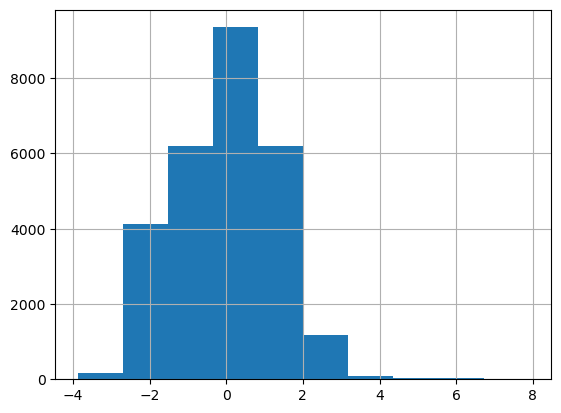

In [33]:
resultados_pca['Componente Principal 1'].hist()

In [42]:
# Crear datos de ejemplo
np.random.seed(42)
df = dfs[['Elevation','Tmin_20']]

# Crear DataFrame
# df = pd.DataFrame(datos)

# Normalizar los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
datos_normalizados = scaler.fit_transform(df)

# Aplicar PCA
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(datos_normalizados)

# Mostrar resultados
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# Convertir a DataFrame con nombres de columnas
resultados_pca = pd.DataFrame(
    componentes_principales,
    columns=['Componente Principal 1', 'Componente Principal 2']
)

print("\nPrimeras 5 filas del resultado PCA:")
print(resultados_pca.head())

dfs['PC1_Elev_Tmin_20']=resultados_pca['Componente Principal 1']

Varianza explicada por cada componente:
[0.87454271 0.12545729]

Primeras 5 filas del resultado PCA:
   Componente Principal 1  Componente Principal 2
0                0.911955               -1.497475
1                0.843733               -1.565698
2                0.379480               -1.078704
3               -0.473814               -0.953115
4               -0.507925               -0.987226


C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_19288\3590371112.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['PC1_Elev_Tmin_20']=resultados_pca['Componente Principal 1']


# Random Forest con PCA

In [63]:
np.random.seed(12)
#'Slope', 'Height', 'Aspect','Magnitude', 'spei6_10', 'Tmax_10', 'Tmin_10', 'Prec_10','NBR_before','Sp_clas'
# variables=['Slope','Aspect', 'Magnitude', 'spei6_20', 'PC1_Tmax_Prec_20','PC1_Elev_Tmin_20', 'Species','NBR_before']
variables=['Aspect', 'Magnitude', 'spei6_20', 'PC1_Tmax_Prec_20','PC1_Elev_Tmin_20', 'Species','NBR_before']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = model_selection.train_test_split(dfs[variables], dfs['Tasa_20'], train_size=0.7)

In [64]:
# LLamada al constructor del random forest utilizando 100 árboles base
RF = RandomForestRegressor(n_estimators=100, random_state=0)
# Entrenamiento del árbol de decisión
RF.fit(X_train, y_train)
# Se realizan las predicciones del árbol de decisión con los ejemplos de entrenamiento
predictionTrain = RF.predict(X_train)
predictionTest = RF.predict(X_test)
importancia=RF.feature_importances_.tolist()
for i in range(len(variables)):
    print(variables[i],': ',importancia[i])

y_pred = RF.predict(X_test)
custom_r2 = r2_score(y_test, y_pred)
print(' ')
print(' ')
print(f"R2 score (custom): {custom_r2}")
custom_rmse = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {custom_rmse}")

Aspect :  0.13643717784894055
Magnitude :  0.23360277975478655
spei6_20 :  0.1525264609928487
PC1_Tmax_Prec_20 :  0.08445172852911444
PC1_Elev_Tmin_20 :  0.12943098208669399
Species :  0.10195081346165968
NBR_before :  0.16160005732595617
 
 
R2 score (custom): 0.3132442044519562
RMSE: 0.0042771082183987565


# Stepwise PCA

In [65]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression

import warnings
warnings.simplefilter("ignore")

In [66]:
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)
variables=['Slope','Aspect', 'Magnitude', 'spei6_20', 'PC1_Tmax_Prec_20','PC1_Elev_Tmin_20', 'Species','NBR_before']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = model_selection.train_test_split(dfs[variables], dfs['Tasa_20'], train_size=0.7)

y = dfs.Tasa_20
X=dfs[variables]

In [ ]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=7,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)

In [68]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=6,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-03-06 11:54:05] Features: 7/6 -- score: 0.3081021394115204

['Magnitude', 'spei6_20', 'PC1_Tmax_Prec_20', 'PC1_Elev_Tmin_20', 'Species', 'NBR_before']
(2, 3, 4, 5, 6, 7)
0.306004808772801



[2025-03-06 11:57:45] Features: 6/6 -- score: 0.306004808772801

In [69]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=5,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-03-06 12:03:32] Features: 7/5 -- score: 0.3081021394115204
[2025-03-06 12:07:11] Features: 6/5 -- score: 0.306004808772801

['Magnitude', 'spei6_20', 'PC1_Elev_Tmin_20', 'Species', 'NBR_before']
(2, 3, 5, 6, 7)
0.29924825083302836



[2025-03-06 12:09:40] Features: 5/5 -- score: 0.29924825083302836

In [70]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=4,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-03-06 12:15:23] Features: 7/4 -- score: 0.3081021394115204
[2025-03-06 12:19:04] Features: 6/4 -- score: 0.306004808772801
[2025-03-06 12:21:36] Features: 5/4 -- score: 0.29924825083302836

['Magnitude', 'spei6_20', 'PC1_Elev_Tmin_20', 'NBR_before']
(2, 3, 5, 7)
0.2844523501433699



[2025-03-06 12:23:27] Features: 4/4 -- score: 0.2844523501433699

In [71]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=3,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-03-06 12:29:21] Features: 7/3 -- score: 0.3081021394115204
[2025-03-06 12:33:09] Features: 6/3 -- score: 0.306004808772801
[2025-03-06 12:35:43] Features: 5/3 -- score: 0.29924825083302836
[2025-03-06 12:37:35] Features: 4/3 -- score: 0.2844523501433699

['Magnitude', 'spei6_20', 'NBR_before']
(2, 3, 7)
0.2422126007231354



[2025-03-06 12:39:04] Features: 3/3 -- score: 0.2422126007231354

In [72]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=2,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-03-06 12:44:53] Features: 7/2 -- score: 0.3081021394115204
[2025-03-06 12:48:35] Features: 6/2 -- score: 0.306004808772801
[2025-03-06 12:51:07] Features: 5/2 -- score: 0.29924825083302836
[2025-03-06 12:52:57] Features: 4/2 -- score: 0.2844523501433699
[2025-03-06 12:54:28] Features: 3/2 -- score: 0.2422126007231354

['Magnitude', 'spei6_20']
(2, 3)
0.08787150443325528



[2025-03-06 12:55:17] Features: 2/2 -- score: 0.08787150443325528

In [73]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=1,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-03-06 13:01:36] Features: 7/1 -- score: 0.3081021394115204
[2025-03-06 13:05:40] Features: 6/1 -- score: 0.306004808772801
[2025-03-06 13:08:25] Features: 5/1 -- score: 0.29924825083302836
[2025-03-06 13:10:24] Features: 4/1 -- score: 0.2844523501433699
[2025-03-06 13:11:55] Features: 3/1 -- score: 0.2422126007231354
[2025-03-06 13:12:44] Features: 2/1 -- score: 0.08787150443325528

['spei6_20']
(3,)
0.1841625698186194



[2025-03-06 13:13:00] Features: 1/1 -- score: 0.1841625698186194

# Dependencias parciales Grafico

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor




In [ ]:
conversor=1/2.54

In [ ]:
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'Prec_5', 'NBR_before', 'Species']

# Suponiendo que join_r es tu dataset con todas las columnas
X = join_r[variables]
y = join_r['Tasa_5']

# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
features = variables

In [ ]:
PartialDependenceDisplay.from_estimator(model, X, features=features)
plt.show()

In [ ]:
features_2d = [('Slope','Magnitude')]  # Especifica las dos características para el gráfico 2D
PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average')
plt.tight_layout()
CS = plt.gca().collections[0]  # Obtiene el conjunto de contornos del gráfico actual
plt.figure(figsize=(8*conversor,8*conversor))
plt.clabel(CS, inline=True, fontsize=10, fmt='%.3f') 
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
plt.show()

In [ ]:
#96db80
#62c59d
#59aca9
#6292aa
#6f75a6
#765491

In [ ]:
from time import time

In [ ]:

# ... (your existing code for model training and data loading) ...

print("Computing partial dependence plots...")
features_info = {
    "features": ['Slope', 'Elevation', ('Slope', 'Elevation')],
    "kind": "average",
}

# Set font to Arial and size 20
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16

_, ax = plt.subplots(ncols=3, figsize=(10, 4), constrained_layout=True)
tic = time()

display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    **features_info,
    ax=ax,
)

print(f"done in {time() - tic:.3f}s")

# # Format axes ticks to 2 decimal places
# for a in ax.ravel():  # Iterate through all axes
#     if a is not None: # Check if the axes exists (for subplot arrangements)
#         a.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
#         a.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
if ax[2] is not None:
    CS = ax[2].collections[0]  # Get the contour set
    ax[2].clabel(CS, inline=True, fontsize=10, fmt='%.3f')  
    
_ = display.figure_.suptitle(
    "Slope and Elevation", fontsize=16  # Ensure title font size is also 20
)


In [ ]:
import mpl_toolkits.mplot3d  # noqa: F401
import numpy as np

from sklearn.inspection import partial_dependence

fig = plt.figure(figsize=(5.5, 5))

features = ('Slope', 'Elevation')
pdp = partial_dependence(
    model, X_train, features=features, kind="average", grid_resolution=10
)
XX, YY = np.meshgrid(pdp["grid_values"][0], pdp["grid_values"][1])
Z = pdp.average[0].T
ax = fig.add_subplot(projection="3d")
fig.add_axes(ax)

surf = ax.plot_surface(XX, YY, Z, rstride=1, cstride=1, cmap=plt.cm.BuPu, edgecolor="k")
ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
fig.suptitle(
    "Slope and Elevation",
    fontsize=16,
)
# pretty init view
ax.view_init(elev=50, azim=135)
clb = plt.colorbar(surf, pad=0.08, shrink=0.6, aspect=10)
clb.ax.set_title("Partial\ndependence")
plt.tight_layout()
plt.show()

In [ ]:

# # Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
# np.random.seed(12)

# # Definir las variables
# variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_20', 'Tmax_20', 'Tmin_20', 'Prec_20', 'NBR_before', 'Sp_clas']

# # Suponiendo que join_r es tu dataset con todas las columnas
# X = join_r[variables]
# y = join_r['Tasa_20']

# # Particionado de los datos en train y test
# X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, train_size=0.7)

# # Crear un modelo Random Forest
# model = RandomForestRegressor(n_estimators=100, random_state=0)

# # Entrenar el modelo
# model.fit(X_train, y_train)

# Función para crear gráficos de dependencia parcial
def plot_partial_dependence(model, feature1, feature2=None):
    fig, ax = plt.subplots(figsize=(7*conversor, 5*conversor))
    
    if feature2:
        PartialDependenceDisplay.from_estimator(
            model,
            X_train,
            [feature1, feature2],
            grid_resolution=50,
            n_jobs=-1,
            ax=ax
            # hist_kws={'density': True, 'color': 'skyblue'}
        )


    else:
        PartialDependenceDisplay.from_estimator(
            model,
            X_train,
            [feature1],
            grid_resolution=50,
            n_jobs=-1,
            ax=ax
            # hist_kws={'density': True, 'color': 'skyblue'}
        )
    
    # plt.title(f'Dependencia parcial del modelo sobre {feature1}')
    # plt.xlabel(feature1)
    # plt.ylabel('Valor predicho')
    
    return fig, ax

# # Graficar combinaciones de pares
# features_pairs = [
#     ('Slope', 'Elevation'),
#     # ('Slope', 'Aspect'),
#     # ('Slope', 'Magnitude'),
#     # ('Height', 'Aspect'),
#     # ('Height', 'Magnitude'),
#     # ('Aspect', 'Magnitude'),
# ]

# fig, axes = plt.subplots(len(features_pairs), 1, figsize=(10, 5*len(features_pairs)))

# for i, (feat1, feat2) in enumerate(features_pairs):
#     fig, ax = plot_partial_dependence(model, feat1, feat2)
#     # axes[i] = ax

# plt.tight_layout()
# plt.show()

# # Guardar los gráficos
# # plt.savefig('partial_dependence_plots.png', dpi=300, bbox_inches='tight')

# print("Gráficos de dependencia parcial creados y guardados como 'partial_dependence_plots.png'")

In [25]:
join_r.columns

Index(['Unnamed: 0', 'Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope',
       'Height', 'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5',
       'Tasa_20', 'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20', 'Y2R_NBR'],
      dtype='object')

In [ ]:
os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Incendios\Organizacion\Resultados\Unido_Tasa5y20\Tasa_post_normalizado_30012025\PDP\pdp')
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_before','Species']

# Suponiendo que join_r es tu dataset con todas las columnas
X = join_r[variables]
y = join_r['Tasa_20']

# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
features = variables

# fig, axes = plt.subplots(len(features), 1, figsize=(10, 5*len(features)))

for i, feature in enumerate(features):
    # fig, ax = plot_partial_dependence(model, feature)

    PartialDependenceDisplay.from_estimator(
            model,
            X_train,
            [feature],
            grid_resolution=50,
            # n_jobs=-1,
            # ax=ax
            # hist_kws={'density': True, 'color': 'skyblue'}
        )

    plt.tight_layout()
    # plt.savefig(f"PDP_tasa20_{feature}.tiff", dpi=300, format="tiff")
# plt.show()

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df=join_r[['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_5', 'Prec_5', 'Tmin_5', 'Tmax_5']]

In [ ]:
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
# os.chdir(r'C:\Users\giambelluca.144055\OneDrive\Incendios\Organizacion\Resultados\Unido_Tasa5y20\Tasa_post_normalizado_30012025\PDP')
os.chdir(r'C:\Users\laugi\OneDrive_backup\3\OneDrive\Incendios\Organizacion\Resultados\Unido_Tasa5y20\Tasa_post_normalizado_30012025\PDP')
np.random.seed(12)

# Definir las variables
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_before']

# Suponiendo que join_r es tu dataset con todas las columnas
X = join_r[variables]
y = join_r['Tasa_20']

# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

# Crear un modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Entrenar el modelo
model.fit(X_train, y_train)
features = variables

# fig, axes = plt.subplots(len(features), 1, figsize=(10, 5*len(features)))
# feat=[('Slope', 'Elevation'),('Slope', 'Aspect'),('Slope', 'Magnitude'),('Slope', 'spei6_20'),('Slope', 'Tmax_20'),('Slope', 'Tmin_20'),('Slope', 'Prec_20'),('Slope', 'NBR_before'),
#    ('Elevation', 'Aspect'),('Elevation', 'Magnitude'),('Elevation', 'spei6_20'),('Elevation', 'Tmax_20'),('Elevation', 'Tmin_20'),('Elevation', 'Prec_20'),('Elevation', 'NBR_before'),
#  ('Aspect', 'Magnitude'),('Aspect', 'spei6_20'),('Aspect', 'Tmax_20'),('Aspect', 'Tmin_20'),('Aspect', 'Prec_20'),('Aspect', 'NBR_before'),
# ('Magnitude', 'spei6_20'),('Magnitude', 'Tmax_20'),('Magnitude', 'Tmin_20'),('Magnitude', 'Prec_20'),('Magnitude', 'NBR_before'),
# ('spei6_20', 'Tmax_20'),('spei6_20', 'Tmin_20'),('spei6_20', 'Prec_20'),('spei6_20', 'NBR_before'),
# ('Tmax_20', 'Tmin_20'),('Tmax_20', 'Prec_20'),('Tmax_20', 'NBR_before'),
# ('Tmin_20', 'Prec_20'),('Tmin_20', 'NBR_before')
# ,('Tmin_20', 'NBR_before')]

feat=[('NBR_before','Tmax_20'),('NBR_before','Tmin_20'),('NBR_before','Prec_20'),('NBR_before','spei6_20'),
('spei6_20', 'Tmax_20'),('spei6_20', 'Tmin_20'),('spei6_20', 'Prec_20'),
('Prec_20', 'Tmax_20'),('Prec_20', 'Tmin_20'),
('Tmin_20','Tmax_20')]
# feat=[('Slope', 'Elevation'),('Slope', 'Aspect'),('Slope', 'Magnitude'),('Slope', 'spei6_5'),('Slope', 'Tmax_5'),('Slope', 'Tmin_5'),('Slope', 'Prec_5'),('Slope', 'NBR_before'),
#    ('Elevation', 'Aspect'),('Elevation', 'Magnitude'),('Elevation', 'spei6_5'),('Elevation', 'Tmax_5'),('Elevation', 'Tmin_5'),('Elevation', 'Prec_5'),('Elevation', 'NBR_before'),
#  ('Aspect', 'Magnitude'),('Aspect', 'spei6_5'),('Aspect', 'Tmax_5'),('Aspect', 'Tmin_5'),('Aspect', 'Prec_5'),('Aspect', 'NBR_before'),
# ('Magnitude', 'spei6_5'),('Magnitude', 'Tmax_5'),('Magnitude', 'Tmin_5'),('Magnitude', 'Prec_5'),('Magnitude', 'NBR_before'),
# ('NBR_before','Tmax_5'),('NBR_before','Tmin_5'),('NBR_before','Prec_5'),('NBR_before','spei6_5'),
# ('spei6_5', 'Tmax_5'),('spei6_5', 'Tmin_5'),('spei6_5', 'Prec_5'),
# ('Prec_5', 'Tmax_5'),('Prec_5', 'Tmin_5'),
# ('Tmin_5','Tmax_5')]



for feature2 in (feat):
    print(feature2)
    features_2d=[feature2]
    plt.figure(figsize=(8*conversor,8*conversor))

    PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average')
    CS = plt.gca().collections[0]  # Obtiene el conjunto de contornos del gráfico actual
    
    plt.clabel(CS, inline=False, fontsize=10, fmt='%.3f') 
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 16
    plt.tight_layout()
    plt.savefig(f"PDP_tasa20_{feature2[0]}_{feature2[1]}.tiff", dpi=300, format="tiff")
   
    plt.show()



# plt.tight_layout()
# plt.show()


# import itertools

# n_rows = 8  # Ajusta el número de filas en tu grid
# n_cols = 8  # Ajusta el número de columnas en tu grid

# fig, axes = plt.subplots(n_rows, n_cols) # Ajusta tamaño figura

# # Aplanar el array de axes para iterar más fácilmente
# axes = axes.flatten()

# for i, feature2 in enumerate(feat):
#     if i < len(axes): #Para evitar error si hay menos graficos que axes.
#         ax = axes[i]
#         features_2d = [feature2]
#         PartialDependenceDisplay.from_estimator(model, X, features=features_2d, kind='average', ax=ax)

#         # CS = ax.collections[0]  # Obtiene el conjunto de contornos del gráfico actual
#         # ax.clabel(CS, inline=False, fontsize=10, fmt='%.3f')
#         ax.set_xlabel(feature2[0])  # Etiqueta el eje x
#         ax.set_ylabel(feature2[1])  # Etiqueta el eje y
#         # ax.tick_params(axis='both', which='major', labelsize=10) #Tamaño de los ticks
#         #ax.set_aspect('equal') #Para que los graficos se vean cuadrados.

    
#     else:
#         break


# # Eliminar los subplots vacíos si hay menos gráficos que axes
# if len(feat) < n_rows * n_cols:
#     for j in range(i + 1, len(axes)):
#         fig.delaxes(axes[j])
        
# plt.tight_layout() # Ajusta el espaciado entre subplots
# # plt.suptitle('Partial Dependence Plots', fontsize=24) #Titulo general
# plt.savefig(f"PDP_tasa5_grid.tiff", dpi=300, format="tiff") #Guardar el grafico completo
# plt.show()

# Prueba

In [ ]:
#Pueba
data = df
variables = ['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'Prec_5', 'NBR_before']

# Suponiendo que join_r es tu dataset con todas las columnas
X = df[variables]
# y = df['Tasa_5']
# Función personalizada para agregar correlaciones

def correlation_matrix(df, model, font_scale=1.2, **kwargs):
    sns.set_context("talk", font_scale=font_scale)
    grid = sns.PairGrid(df, **kwargs)

    def hist_with_freq(x, **kwargs):
        sns.histplot(x, kde=True, **kwargs)
        ax = plt.gca()
        ax.set_ylabel("Frecuencia")

    grid.map_lower(sns.scatterplot, alpha=0.5)
    grid.map_diag(hist_with_freq)

    def dependance(x, y, **kwargs):
        # Asegúrate de que x e y sean columnas del DataFrame original
        feature_1 = x.name  # Obtener el nombre de la columna
        feature_2 = y.name
        features_2d = [(feature_1, feature_2)]

        # Crear una nueva figura para cada gráfico de dependencia parcial
        fig, ax = plt.subplots(figsize=(8, 8))  # Ajusta el tamaño según necesites
        PartialDependenceDisplay.from_estimator(model, df[variables],  # Usar el DataFrame original
                                                features=features_2d, kind='average', ax=ax)

        # CS = ax.collections[0]  # Obtiene el conjunto de contornos del gráfico actual
        # ax.clabel(CS, inline=True, fontsize=10, fmt='%.3f')
        # plt.tight_layout()
        # Formatear las etiquetas DESPUÉS de que se dibuje el gráfico
        # try:
        #     CS = ax.collections[0]  # Intenta obtener las colecciones
        #     ax.clabel(CS, inline=True, fontsize=10, fmt='%.3f')
        # except IndexError:
        #     # print(f"No se encontraron contornos para {feature_1} vs {feature_2}")
            

        plt.tight_layout()  # Llama a tight_layout DESPUÉS de formatear las etiquetas

    grid.map_upper(dependance)
    return grid

    # grid.map_upper(dependance)
    # return grid

# Generar la visualización. Pasa el modelo a la función
g = correlation_matrix(data, model, font_scale=1.2, corner=False)

for i, ax in enumerate(g.axes.flat):
    row = i // g.axes.shape[1]
    col = i % g.axes.shape[1]
    if row < col:
        ax.tick_params(bottom=False, left=False)

plt.rcParams["font.family"] = "Arial"
plt.show()

In [ ]:
len(join_r)

# Correlacion

In [25]:
df=dfs[['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_5', 'Prec_5', 'Tmin_5', 'Tmax_5', 'Tasa_5']]
df.columns=['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_5', 'Prec_5', 'Tmin_5', 'Tmax_5', 'Rate_5']

In [20]:
df.groupby('Species')['Species'].count()

Species
1.0      3338
2.0     13455
3.0       485
4.0        29
5.0       189
6.0       144
7.0       647
8.0      3286
9.0         5
10.0       21
11.0     3901
12.0       25
13.0       62
14.0     1800
Name: Species, dtype: int64

In [ ]:
len(df)

In [26]:
os.chdir('C:\\Users\\laugi\\OneDrive_backup\\3\\OneDrive\\Doctorado\\Articulos\\Wildfire\\Imagenes\\18022025')

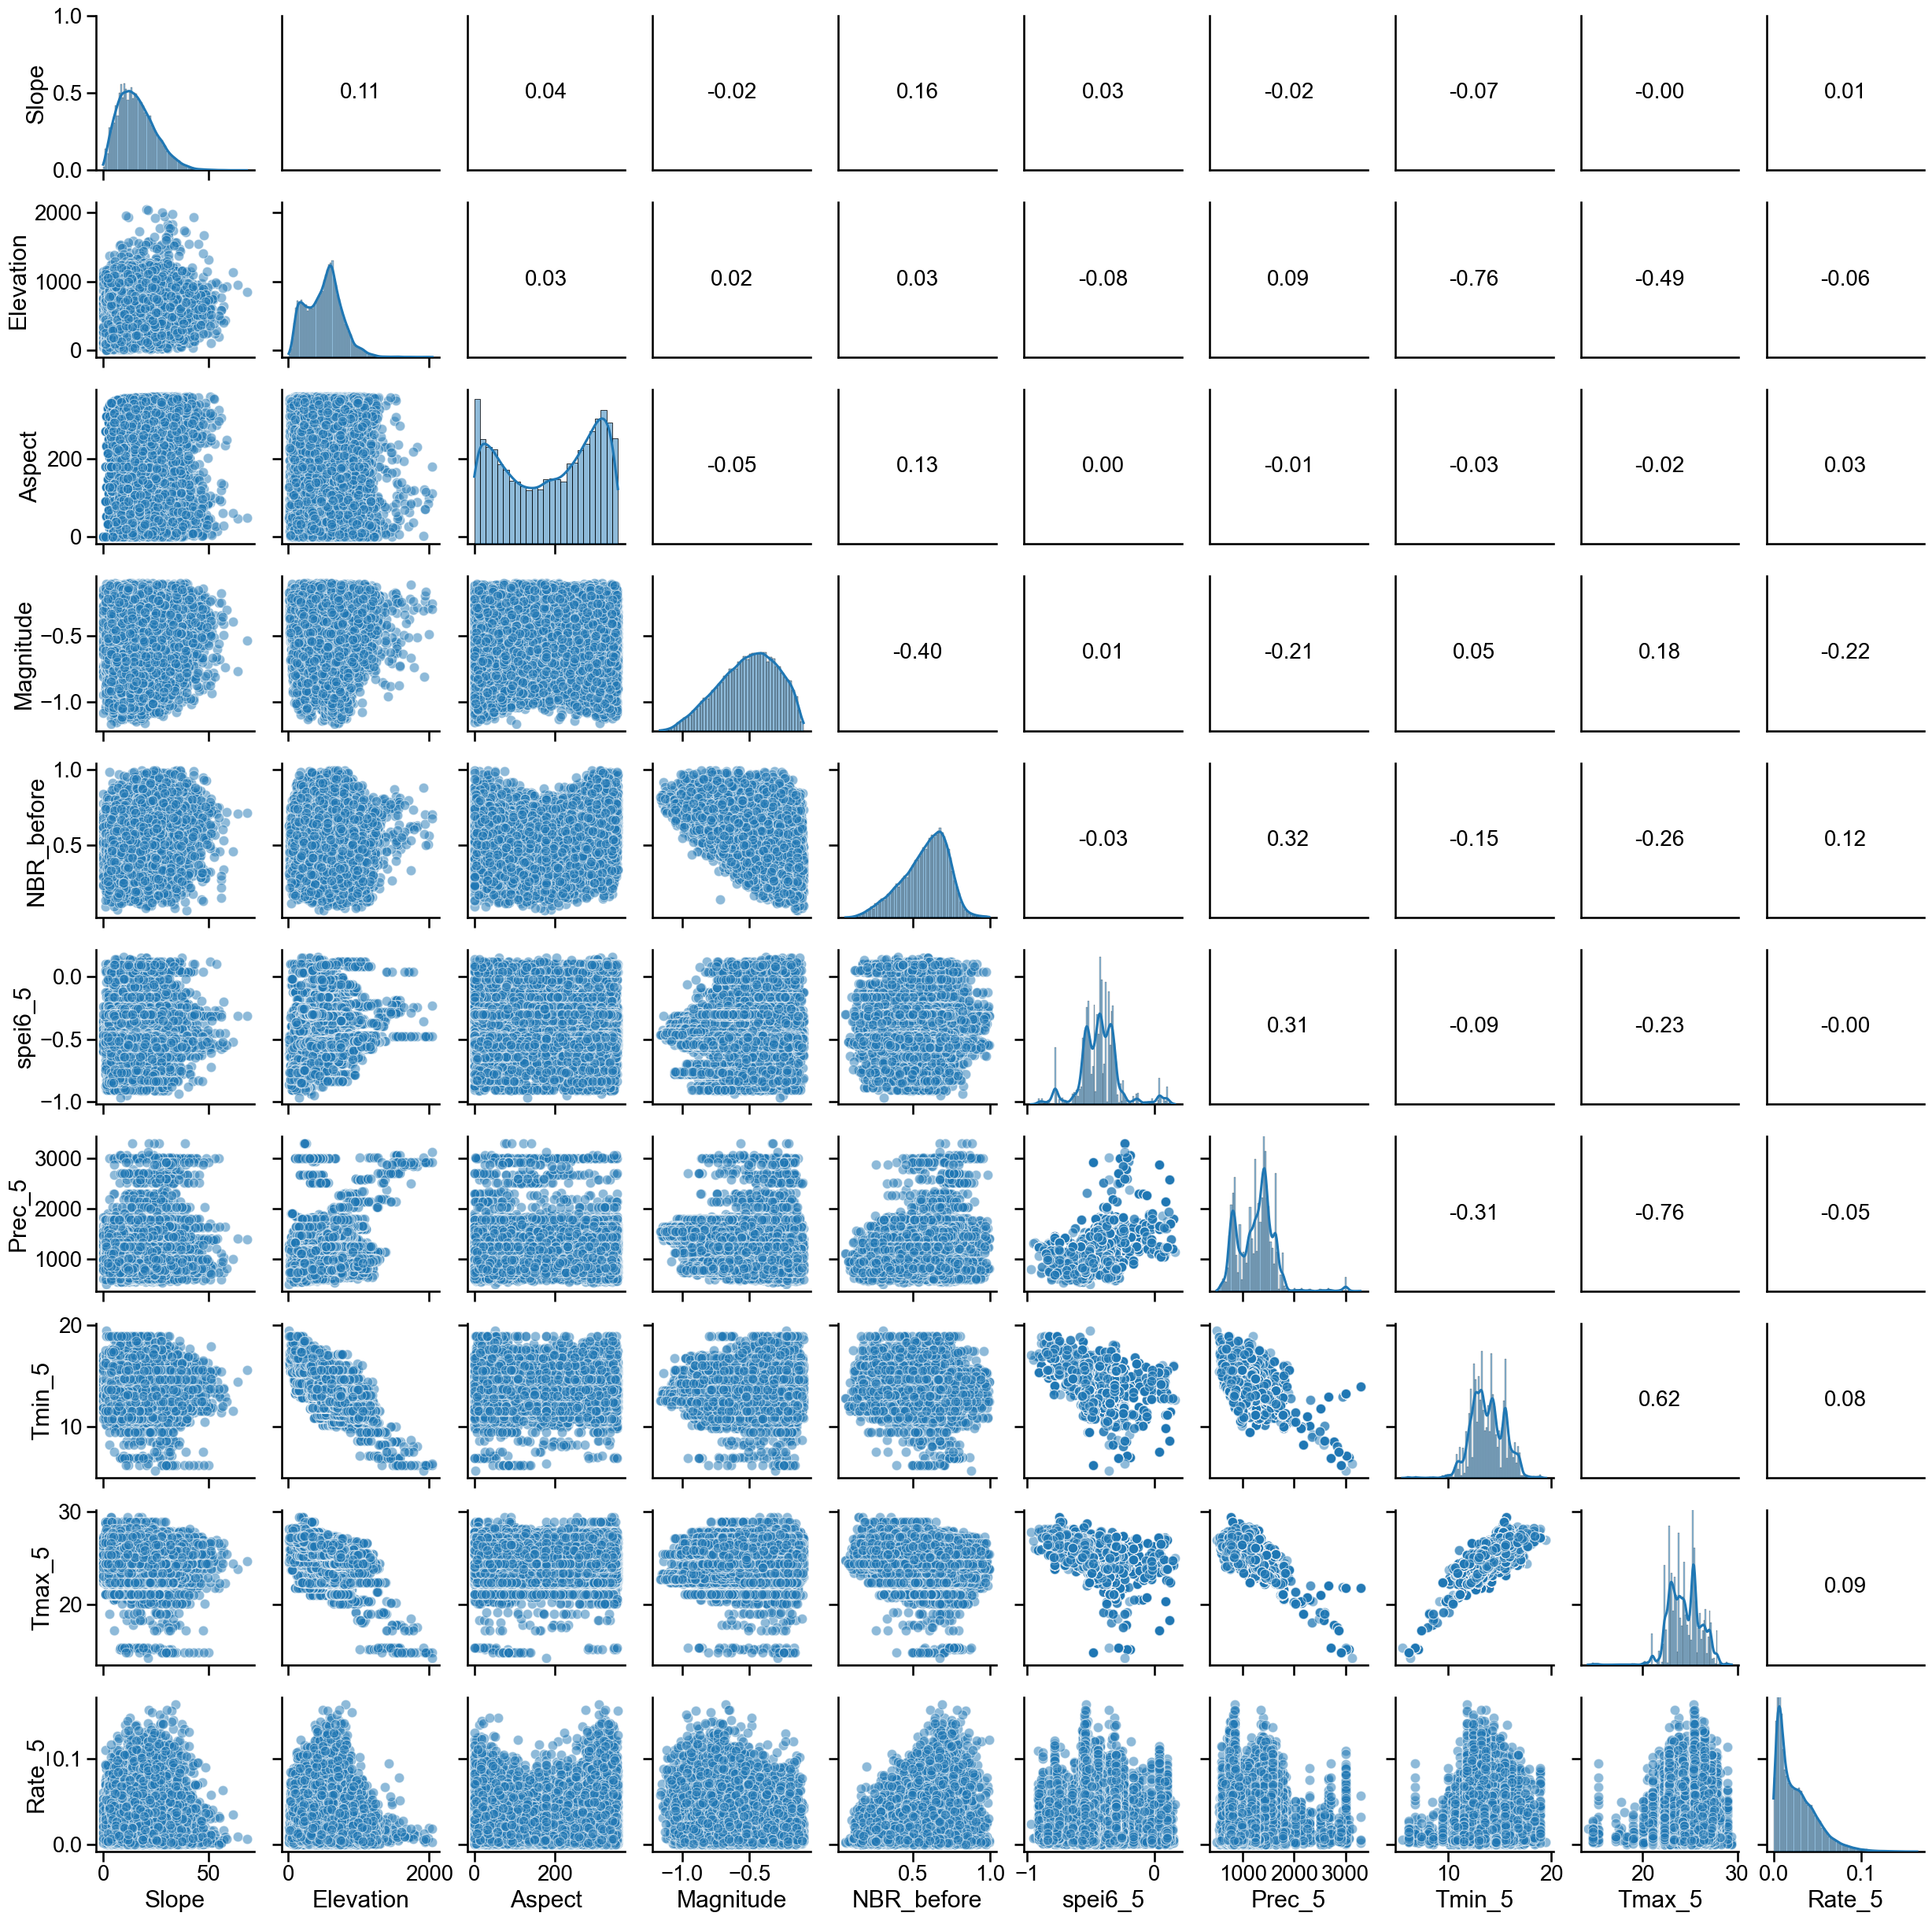

In [27]:

# Simulamos un DataFrame con 10 variables predictoras y 1 variable a predecir
np.random.seed(42)
data = df

# Función personalizada para agregar correlaciones
def correlation_matrix(df,font_scale=1.2, value_fontsize=20, **kwargs):
    
    # Crea el grid de PairGrid
    sns.set_context("talk", font_scale=font_scale)
    grid = sns.PairGrid(df, **kwargs)

    def hist_with_freq(x, **kwargs):
        sns.histplot(x, kde=True, **kwargs)
        ax = plt.gca()
        ax.set_ylabel("Frecuencia")
        # Ajustar los límites del eje y para la mitad inferior
        if ax.get_position().y0 <= 0.5:  # Si estamos en la mitad inferior
            ax.set_ylim(bottom=0)  # Asegurar que el límite inferior sea 0

    grid.map_lower(sns.scatterplot, alpha=0.5)
    grid.map_diag(hist_with_freq)



    # Añadir valores de correlación en la parte superior
    def corr_coeff(x, y, **kwargs):
        corr = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"{corr:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes, 
                    ha="center", va="center", fontsize=value_fontsize, color="black")
    grid.map_upper(corr_coeff)
    


    return grid

# Generar la visualización
g = correlation_matrix(data,font_scale=1.2, value_fontsize=20, corner=False)
for i, ax in enumerate(g.axes.flat):
    row = i // g.axes.shape[1]
    col = i % g.axes.shape[1]
    if row < col:  # Mitad superior
        ax.tick_params(bottom=False, left=False)
# plt.suptitle('Relación entre variables y correlaciones', y=1.02)

plt.rcParams["font.family"] = "Arial"
plt.savefig(f"tasa5_ correlaciones.tiff", dpi=300, format="tiff")
# plt.show()

In [31]:
df_20=join_r[['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_20', 'Prec_20', 'Tmin_20', 'Tmax_20', 'Tasa_20']]
df_20.columns=['Slope','Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_20', 'Prec_20', 'Tmin_20', 'Tmax_20', 'Rate_20']

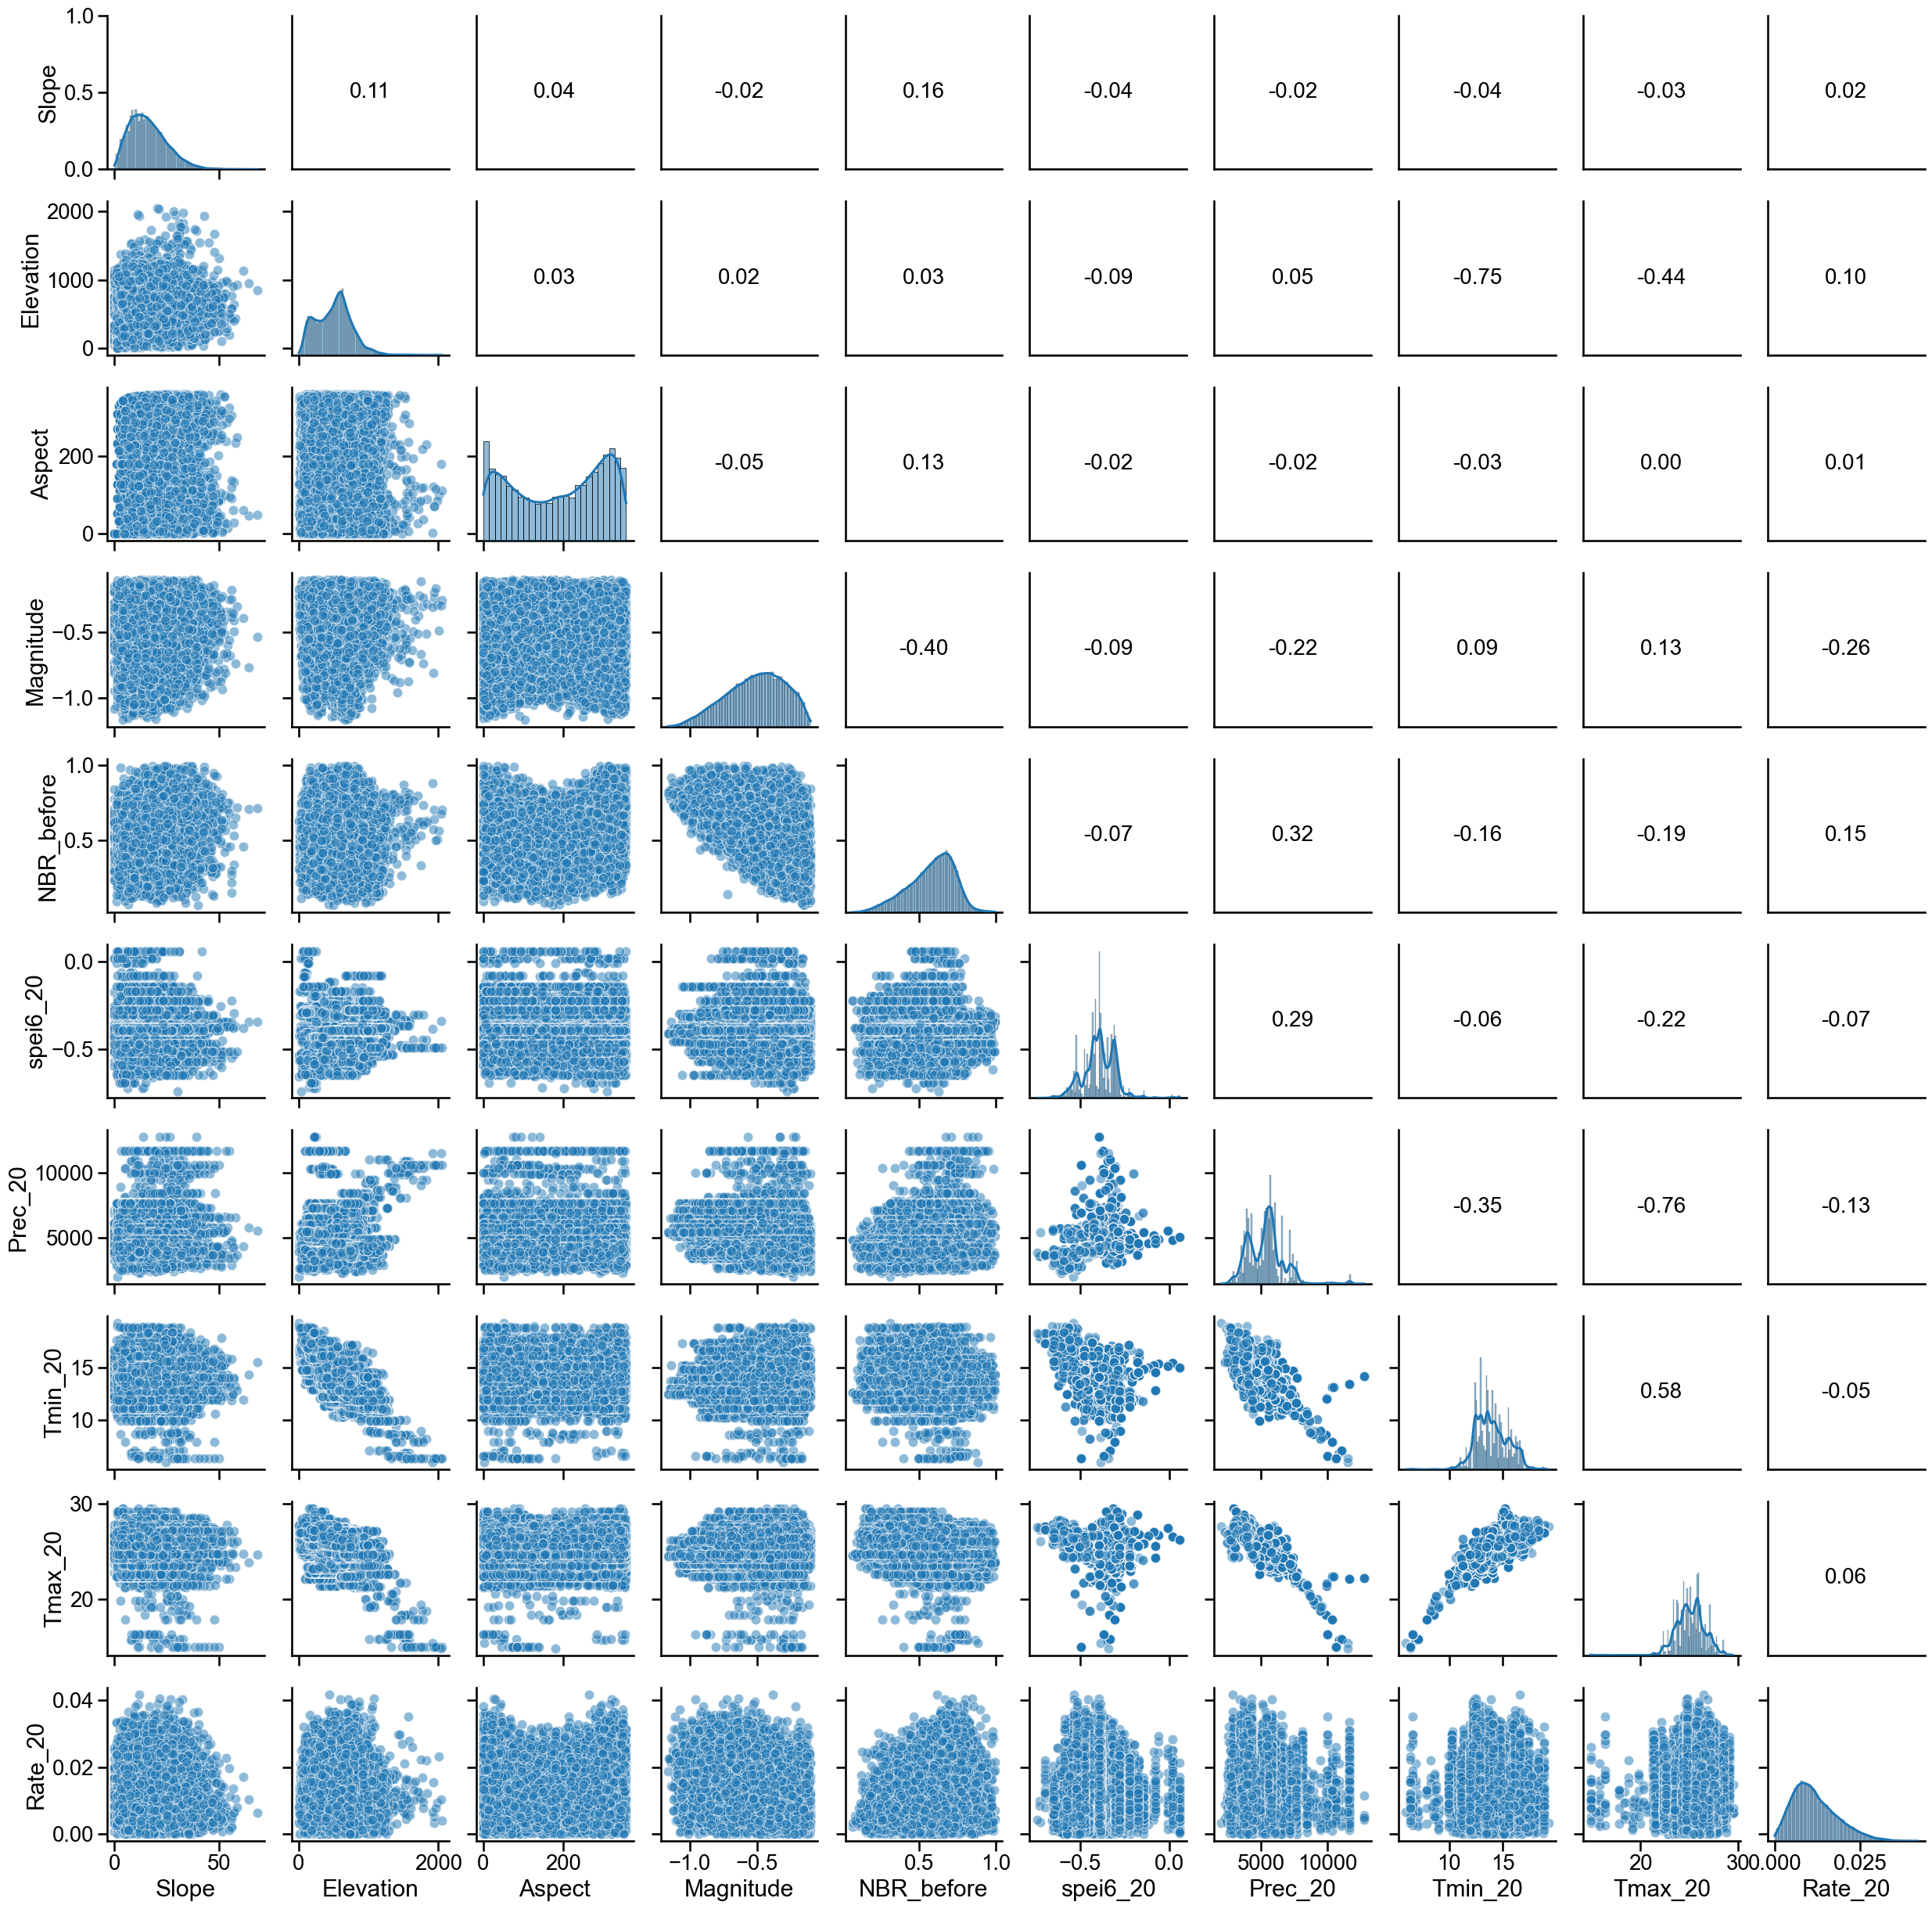

In [32]:
# Simulamos un DataFrame con 10 variables predictoras y 1 variable a predecir
np.random.seed(42)
data = df_20

# Función personalizada para agregar correlaciones
def correlation_matrix(df,font_scale=1.2, value_fontsize=20, **kwargs):
    
    # Crea el grid de PairGrid
    sns.set_context("talk", font_scale=font_scale)
    grid = sns.PairGrid(df, **kwargs)

    def hist_with_freq(x, **kwargs):
        sns.histplot(x, kde=True, **kwargs)
        ax = plt.gca()
        ax.set_ylabel("Frecuencia")
        # Ajustar los límites del eje y para la mitad inferior
        if ax.get_position().y0 <= 0.5:  # Si estamos en la mitad inferior
            ax.set_ylim(bottom=0)  # Asegurar que el límite inferior sea 0

    grid.map_lower(sns.scatterplot, alpha=0.5)
    grid.map_diag(hist_with_freq)



    # Añadir valores de correlación en la parte superior
    def corr_coeff(x, y, **kwargs):
        corr = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"{corr:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes, 
                    ha="center", va="center", fontsize=value_fontsize, color="black")
    grid.map_upper(corr_coeff)
    
    return grid

# Generar la visualización
g = correlation_matrix(data,font_scale=1.2, value_fontsize=20, corner=False)
for i, ax in enumerate(g.axes.flat):
    row = i // g.axes.shape[1]
    col = i % g.axes.shape[1]
    if row < col:  # Mitad superior
        ax.tick_params(bottom=False, left=False)
# plt.suptitle('Relación entre variables y correlaciones', y=1.02)
plt.rcParams["font.family"] = "Arial"
plt.savefig(f"tasa20_ correlaciones.tiff", dpi=300, format="tiff")
# plt.show()

In [ ]:
df.Prec.min()

In [ ]:
df_5=join_r[['Slope', 'Height', 'Aspect','Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'Prec_5', 'NBR_before','Sp_clas','Tasa_5']]

In [ ]:
df_5.columns=['Slope', 'Elevation', 'Aspect','Magnitude', 'Spei', 'Tmax', 'Tmin', 'Prec', 'NBR before','Species','Tasa_5']

In [ ]:
df_5.corr().to_clipboard()

In [ ]:
rates=join_r[['Tasa_5','Tasa_20','Y2R_NBR']]
rates.corr().to_clipboard()

In [ ]:
rates.Tasa_20.mean()

In [ ]:
# Simulamos un DataFrame con 10 variables predictoras y 1 variable a predecir
np.random.seed(42)
data = df_5

# Función personalizada para agregar correlaciones
def correlation_matrix(df,font_scale=1.2, value_fontsize=18, **kwargs):
    
    # Crea el grid de PairGrid
    sns.set_context("talk", font_scale=font_scale)
    grid = sns.PairGrid(df, **kwargs)

    def hist_with_freq(x, **kwargs):
        sns.histplot(x, kde=True, **kwargs)
        ax = plt.gca()
        ax.set_ylabel("Frecuencia")
        # Ajustar los límites del eje y para la mitad inferior
        if ax.get_position().y0 <= 0.5:  # Si estamos en la mitad inferior
            ax.set_ylim(bottom=0)  # Asegurar que el límite inferior sea 0

    grid.map_lower(sns.scatterplot, alpha=0.5)
    grid.map_diag(hist_with_freq)



    # Añadir valores de correlación en la parte superior
    def corr_coeff(x, y, **kwargs):
        corr = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(f"{corr:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes, 
                    ha="center", va="center", fontsize=value_fontsize, color="black")
    grid.map_upper(corr_coeff)
    
    return grid

# Generar la visualización
g = correlation_matrix(data,font_scale=1.2, value_fontsize=18, corner=False)
for i, ax in enumerate(g.axes.flat):
    row = i // g.axes.shape[1]
    col = i % g.axes.shape[1]
    if row < col:  # Mitad superior
        ax.tick_params(bottom=False, left=False)
# plt.suptitle('Relación entre variables y correlaciones', y=1.02)
plt.rcParams["font.family"] = "Arial"
plt.show()

In [ ]:

# ... (cargar datos y entrenar modelo)

# Crear PDP para 'Aspecto' y 'Temperatura'
features = ['Aspect', 'Tmax_20']
pdp_interact = pdp.pdp_interact(RF, dataset=join_r, model_features=features, num_grid_points=[20, 20])
fig, axes = pdp.pdp_interact_plot(pdp_interact, feature_names=features, plot_type='surface')
plt.show()

In [ ]:
df

In [ ]:
correlaciones=join_r[['Slope', 'Height', 'Aspect','Magnitude', 'spei6_20', 'Tmax_20', 'Tmin_20', 'Prec_20','NBR_before','Tasa_20','Sp_clas']]
cor=correlaciones.corr(method='pearson')
cor.to_clipboard()

In [ ]:
residuales = y_test - y_pred

import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de residuales
plt.figure(figsize=(10, 6))
sns.residplot(x=y_test, y=y_pred)
# Calcular el R2
r2 = r2_score(y_test, y_pred)

# Annotar el R2 en el gráfico
plt.annotate(f'R²: {r2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
# Mostrar el gráfico
plt.title('Gráfico de Residuales')
plt.xlabel('Valores previstos')
plt.ylabel('Residuales')
plt.show()

# ExhaustiveFeatureSelector

In [ ]:
os.getcwd()
os.chdir('C:\\Users\\giambelluca.144055\\OneDrive\\Incendios\\Organizacion\\Tasa')

In [ ]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

In [ ]:
join_r=pd.read_csv('Usar_tasa_CCAA.csv')

In [ ]:
y = join_r.Tasa
X=join_r[['Slope', 'Height', 'Aspect','Magnitude', 'spei6_10', 'Tmax_10', 'Tmin_10', 'Prec_10','NBR_before','Sp_clas']]
RF = RandomForestRegressor(n_estimators=500, random_state=0)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

efs1 = EFS(RF, 
           min_features=1,
           max_features=10,
           scoring='neg_mean_squared_error',
           print_progress=True,
           cv=5)



In [ ]:
efs=efs1.fit(X_train, y_train)

In [ ]:
# pip install --upgrade mlxtend

In [ ]:
# efs2 = efs1.fit(X, y)


In [ ]:
print(efs1.best_score)

In [ ]:
efs1

In [ ]:

print('Best accuracy score: %.2f' % efs1.best_score_)
print('Best subset (indices):', efs1.best_idx_)
print('Best subset (corresponding names):', efs1.best_feature_names_)

# Setpwise

In [ ]:
pip install mlxtend

In [ ]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression

import warnings
warnings.simplefilter("ignore")

In [17]:
len(join_r)

27387

In [18]:
join_r.columns

Index(['Unnamed: 0', 'Row', 'ID', 'year_recovery', 'FECHA', 'Label', 'Slope',
       'Elevation', 'Aspect', 'Magnitude', 'NBR_before', 'Especie1', 'Tasa_5',
       'Tasa_20', 'spei6_5', 'spei6_20', 'Prec_5', 'Prec_20', 'Tmin_5',
       'Tmin_20', 'Tmax_5', 'Tmax_20', 'Y2R_NBR', 'Species'],
      dtype='object')

In [27]:
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)
variables=['Slope', 'Elevation', 'Aspect','Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_before','Species']
# Particionado de los datos en train y test
X_train, X_test, y_train, y_test = model_selection.train_test_split(join_r[variables], join_r['Tasa_5'], train_size=0.7)

In [28]:
y = join_r.Tasa_5
X=join_r[variables]

In [29]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=9,
forward=False,
verbose=3,
# scoring="neg_mean_squared_error"
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)

['Slope', 'Elevation', 'Aspect', 'Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'Prec_5', 'NBR_before']
(0, 1, 2, 3, 4, 5, 6, 7, 8)
0.25876811670260697



[2025-02-20 16:43:51] Features: 9/9 -- score: 0.25876811670260697

In [30]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=8,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 16:52:25] Features: 9/8 -- score: 0.25876811670260697

['Slope', 'Elevation', 'Aspect', 'Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'NBR_before']
(0, 1, 2, 3, 4, 5, 6, 8)
0.25883621317446825



[2025-02-20 17:04:49] Features: 8/8 -- score: 0.25883621317446825

In [31]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=7,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 17:24:22] Features: 9/7 -- score: 0.25876811670260697
[2025-02-20 17:35:44] Features: 8/7 -- score: 0.25883621317446825

['Elevation', 'Aspect', 'Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'NBR_before']
(1, 2, 3, 4, 5, 6, 8)
0.2595682639057916



[2025-02-20 17:48:53] Features: 7/7 -- score: 0.2595682639057916

In [32]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=6,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 18:02:01] Features: 9/6 -- score: 0.25876811670260697
[2025-02-20 18:14:16] Features: 8/6 -- score: 0.25883621317446825
[2025-02-20 18:27:10] Features: 7/6 -- score: 0.2595682639057916

['Elevation', 'Aspect', 'Magnitude', 'spei6_5', 'Tmax_5', 'NBR_before']
(1, 2, 3, 4, 5, 8)
0.25010849464645757



[2025-02-20 18:33:35] Features: 6/6 -- score: 0.25010849464645757

In [33]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=5,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 18:47:01] Features: 9/5 -- score: 0.25876811670260697
[2025-02-20 18:53:42] Features: 8/5 -- score: 0.25883621317446825
[2025-02-20 18:59:12] Features: 7/5 -- score: 0.2595682639057916
[2025-02-20 19:03:10] Features: 6/5 -- score: 0.25010849464645757

['Elevation', 'Magnitude', 'spei6_5', 'Tmax_5', 'NBR_before']
(1, 3, 4, 5, 8)
0.24115917602086726



[2025-02-20 19:06:16] Features: 5/5 -- score: 0.24115917602086726

In [34]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=4,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 19:14:50] Features: 9/4 -- score: 0.25876811670260697
[2025-02-20 19:21:35] Features: 8/4 -- score: 0.25883621317446825
[2025-02-20 19:27:18] Features: 7/4 -- score: 0.2595682639057916
[2025-02-20 19:31:17] Features: 6/4 -- score: 0.25010849464645757
[2025-02-20 19:34:21] Features: 5/4 -- score: 0.24115917602086726

['Elevation', 'Magnitude', 'Tmax_5', 'NBR_before']
(1, 3, 5, 8)
0.21118706205268395



[2025-02-20 19:36:22] Features: 4/4 -- score: 0.21118706205268395

In [35]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=3,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 19:44:53] Features: 9/3 -- score: 0.25876811670260697
[2025-02-20 19:51:35] Features: 8/3 -- score: 0.25883621317446825
[2025-02-20 19:57:06] Features: 7/3 -- score: 0.2595682639057916
[2025-02-20 20:01:05] Features: 6/3 -- score: 0.25010849464645757
[2025-02-20 20:04:11] Features: 5/3 -- score: 0.24115917602086726
[2025-02-20 20:06:12] Features: 4/3 -- score: 0.21118706205268395

['Magnitude', 'Tmax_5', 'NBR_before']
(3, 5, 8)
0.17458716903086183



[2025-02-20 20:07:40] Features: 3/3 -- score: 0.17458716903086183

In [36]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=2,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 20:16:10] Features: 9/2 -- score: 0.25876811670260697
[2025-02-20 20:22:51] Features: 8/2 -- score: 0.25883621317446825
[2025-02-20 20:28:22] Features: 7/2 -- score: 0.2595682639057916
[2025-02-20 20:32:20] Features: 6/2 -- score: 0.25010849464645757
[2025-02-20 20:35:27] Features: 5/2 -- score: 0.24115917602086726
[2025-02-20 20:37:27] Features: 4/2 -- score: 0.21118706205268395
[2025-02-20 20:38:55] Features: 3/2 -- score: 0.17458716903086183

['Magnitude', 'Tmax_5']
(3, 5)
0.04086988866468557



[2025-02-20 20:39:45] Features: 2/2 -- score: 0.04086988866468557

In [37]:
# linearreg = LinearRegression()
RF = RandomForestRegressor(n_estimators=100, random_state=0)
forwad = SequentialFeatureSelector(
RF,
k_features=1,
forward=False,
verbose=3,
scoring='r2'
)
sf = forwad.fit(X_train,y_train)

feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)


[2025-02-20 20:48:15] Features: 9/1 -- score: 0.25876811670260697
[2025-02-20 20:54:57] Features: 8/1 -- score: 0.25883621317446825
[2025-02-20 21:00:28] Features: 7/1 -- score: 0.2595682639057916
[2025-02-20 21:04:27] Features: 6/1 -- score: 0.25010849464645757
[2025-02-20 21:07:33] Features: 5/1 -- score: 0.24115917602086726
[2025-02-20 21:09:34] Features: 4/1 -- score: 0.21118706205268395
[2025-02-20 21:11:02] Features: 3/1 -- score: 0.17458716903086183
[2025-02-20 21:11:52] Features: 2/1 -- score: 0.04086988866468557

['Tmax_5']
(5,)
0.1654096183276748



[2025-02-20 21:12:09] Features: 1/1 -- score: 0.1654096183276748

In [45]:
feat_names = list(sf.k_feature_names_)
print(feat_names)

print(sf.k_feature_idx_)
print(sf.k_score_)

['Slope', 'Elevation', 'Aspect', 'Magnitude', 'spei6_5', 'Tmax_5', 'Prec_5', 'NBR_before', 'Species']
(0, 1, 2, 3, 4, 5, 7, 8, 9)
-0.0004040116695755259


In [42]:
# Obtener los índices de las características seleccionadas
indices_caracteristicas = sf.k_feature_idx_

# Obtener los scores (error cuadrático medio negativo) para cada combinación
scores = sf.k_score_

# Mostrar los resultados
print("\nCaracterísticas seleccionadas:")
for i, idx in enumerate(indices_caracteristicas):
    print(f"Paso {i+1}: Característica {idx}")

print("\nScores (error cuadrático medio negativo):")
for i, score in enumerate(scores):
    print(f"Paso {i+1}: {-score:.4f}")  # Multiplicamos por -1 para ver el ECM positivo


Características seleccionadas:
Paso 1: Característica 0
Paso 2: Característica 2
Paso 3: Característica 3
Paso 4: Característica 4
Paso 5: Característica 5
Paso 6: Característica 6
Paso 7: Característica 7
Paso 8: Característica 8
Paso 9: Característica 9

Scores (error cuadrático medio negativo):


TypeError: 'numpy.float64' object is not iterable

In [ ]:
import statsmodels.api as sm

X = np.append(arr=np.ones((len(join_r),1)).astype(int),values = X, axis=1)
# print(X)
X_opt = X[:,[0, 3, 6, 8]]
regressor_OLS = sm.OLS(endog=y,exog=X_opt).fit()
regressor_OLS.summary()

A low P-value (<0.05) mean that the coefficients is likely not equal to zero.

A high p-value(>0.05) means that we cannot conclude that the explanatory variable affect the dependent variable. A high P-value is also called an insignificant P-value.'

In [ ]:
# Backware

In [ ]:
linearreg2 = LinearRegression()
fowad = SequentialFeatureSelector(linearreg2,k_features=9,forward=False,verbose=3,scoring="r2")
sf1 = fowad.fit(X,y)

feat_names = list(sf1.k_feature_names_)
print(feat_names)

print(sf1.k_feature_idx_)


In [ ]:
sf1.k_score_

In [ ]:
corre=join_r[['Slope', 'Height', 'Aspect','Magnitude', 'NBR_before','spei6_b', 'spei6_5', 'spei6_10', 'Tmax_b', 'Tmax_5', 'Tmax_10', 'Tmin_b', 'Tmin_5','Tmin_10','Prec_b', 'Prec_5', 'Prec_10', 'Sp_clas','Rate','Y2R_NBR']]

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

# Suponiendo que tienes un DataFrame llamado 'data'
corr_matrix = corre.corr(method='spearman')
corr_matrix.to_clipboard()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt

# # Crear un modelo de bosque aleatorio
# rf = RandomForestRegressor(n_estimators=100)
# rf.fit(X_train, y_train)

# Calcular la dependencia parcial de la característica 0
features = [0]
feature_names=['Slope', 'Height', 'Aspect','Magnitude', 'spei6_5', 'Tmax_5', 'Tmin_5', 'Prec_5','NBR_before','Sp_clas']
fig, axs = plt.subplots(1, len(features), figsize=(12, 4))


for i, feature in enumerate(features):
  # Use PartialDependenceDisplay
  pdp = partial_dependence(RF, X_train, features=[feature])
#   pdp.plot(feature_names=feature_names, ax=axs[i])

# plt.show()

In [ ]:
pdp

# Analisis

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
pca_var=corre[[ 'Height','Slope', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_b',
       'Tmax_b',  'Tmin_b', 'Prec_b', 'Sp_clas']]

In [ ]:
lista=['Slope', 'Height', 'Aspect', 'Magnitude', 'NBR_before', 'spei6_b',
       'Tmax_b',  'Tmin_b', 'Prec_b', 'Sp_clas']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(pca_var)

In [ ]:
pca = PCA()

In [ ]:
principalComponents = pca.fit_transform(data_scaled)

In [ ]:
# Porcentaje de varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_


# Visualizar la varianza explicada acumulada
plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.show()

In [ ]:
for i in range(len(explained_variance)):
    print(lista[i],': ',explained_variance[i])

In [ ]:
df_components = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2', 'PC3', 'PC4','PC5', 'PC6', 'PC7', 'PC8','PC9', 'PC10'])

In [ ]:
df_components

In [ ]:
correlaciones=join_r[['Slope', 'Height','Aspect', 'Magnitude', 'NBR_before', 'Prec_b','Prec_5','Prec_10','Tmax_b','Tmax_5', 'Tmin_b',
         'Tmin_5', 'spei6_b','spei6_5', 'Sp_clas', 'Y2R_NBR', 'Rate']]

In [ ]:
c=correlaciones.corr()
c.to_clipboard()

In [ ]:
menos5=join_r.loc[join_r.Y2R_NBR>1]
len(menos5)

In [ ]:
cor=join_r[['Slope', 'Height', 'Aspect','Magnitude', 'spei6', 'spei6_5', 'Tmax','Tmax_5', 'Tmin','Tmin_5','PP', 'PP_5','NBR_before','Y2R_NBR']]

In [ ]:
exp=cor.corr()

In [ ]:
exp.to_clipboard()

In [ ]:
exp.to_csv('Cor_Navarra.csv')

In [ ]:
join_r.Y2R_NBR.hist()

In [ ]:
join_r.groupby('Y2R_NBR')['Row'].count()

In [ ]:
# join_r.loc[(join_r.Y2R_NBR<=3),['Class']]='3'
# join_r.loc[(join_r.Y2R_NBR>3)&(join_r.Y2R_NBR<=5),['Class']]='3-5'
# join_r.loc[(join_r.Y2R_NBR>5)&(join_r.Y2R_NBR<=8),['Class']]='5-8'
# join_r.loc[(join_r.Y2R_NBR>8)&(join_r.Y2R_NBR<=10),['Class']]='8-10'
# join_r.loc[(join_r.Y2R_NBR>10)&(join_r.Y2R_NBR<=15),['Class']]='10-15'
# join_r.loc[(join_r.Y2R_NBR>15),['Class']]='>15'

join_r.loc[(join_r.Y2R_NBR<=5),['Class']]='5'
join_r.loc[(join_r.Y2R_NBR>5)&(join_r.Y2R_NBR<=10),['Class']]='5-10'
join_r.loc[(join_r.Y2R_NBR>10)&(join_r.Y2R_NBR<=15),['Class']]='10-15'
join_r.loc[(join_r.Y2R_NBR>15)&(join_r.Y2R_NBR<=20),['Class']]='15-20'
join_r.loc[(join_r.Y2R_NBR>20),['Class']]='>20'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Crear el histograma
plt.hist(join_r.Y2R_NBR, bins=10)

# Personalizar el gráfico
plt.title("Y2R ")
plt.xlabel("Y2R")
plt.ylabel("Frequency")
plt.grid(False)

# Mostrar el gráfico
plt.show()

In [ ]:
join_r.Rate.min()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Validacion cruzada


# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)

# Realizamos el proceso para KNN por lo que hay que llamar al constructor de dicho clasificador
RF = RandomForestClassifier()
# Se define el grid de parámetros a utilizar
    # Estos parámetros nos darán todas las posibles configuraciones del clasificador KNN
        # Cada combinación de parámetros es una configuración diferente
param_grid = {'n_estimators': [10,50,100], 'max_features': [1,'sqrt','log2',None], 'criterion': ['gini', 'entropy'], 'max_depth': [5,10,None], 'min_samples_split': [2,10,20]}

# Llamada la función GridSearchCV que nos crea todas las cominaciones del grid anterior
clasificadoresRF = model_selection.GridSearchCV(RF, param_grid, scoring='accuracy', cv=10, return_train_score=True)

# Entrenamiento de todos los clasificadores con todos los datos contenidos en iris (campos data y target, es decir X e y, respectivamente)
clasificadoresRF = clasificadoresRF.fit(m[['Slope', 'Height','TRASP', 'Magnitude', 'fVPD_5', 'fVPD_10', 'fTemp_5', 'fTemp_10','fSW_5', 'fSW_10', 'fTemp_b', 'fVPD_b', 'fSW_b']], m['Class'])

# Se muestra la mejor configuración y su accuracy asociado
print(clasificadoresRF.best_params_)
print(clasificadoresRF.best_score_)

# Se muestra el accuracy obtenido para cada posible combinación de parámetros
resultadosMostrar = zip(clasificadoresRF.cv_results_['params'],clasificadoresRF.cv_results_['mean_test_score'],clasificadoresRF.cv_results_['mean_train_score'])
for params, mean_test_score, mean_train_score in resultadosMostrar:
    print("%0.3f (Train: %0.3f) for %r" % (mean_test_score, mean_train_score, params))
print()

In [ ]:
fil=join_r.loc[(join_r.Y2R_NBR>1)]

In [ ]:
join_r.groupby('Class')['Class'].count()

In [ ]:
C1=join_r.loc[(join_r.Class=='5')].sample(3065,random_state=12)
C2=join_r.loc[(join_r.Class=='5-10')].sample(3065,random_state=12)
C3=join_r.loc[(join_r.Class=='10-15')].sample(3065,random_state=12)
C4=join_r.loc[(join_r.Class=='15-20')].sample(3065,random_state=12)
C5=join_r.loc[(join_r.Class=='>20')].sample(3065,random_state=12)


m=pd.concat([C1,C2,C3,C4,C5])

# C1=fil.loc[(fil.Class=='5')].sample(3065,random_state=12)
# C2=fil.loc[(fil.Class=='5-15')].sample(3065,random_state=12)
# C3=fil.loc[(fil.Class=='>15')].sample(3065,random_state=12)

# m=pd.concat([C1,C2,C3])

In [ ]:
# Se importa el paquete de métricas de rendimiento
from sklearn import metrics, model_selection
# Se fija la semilla de numpy para que la generación aleatoria siempre nos de los mismos números
np.random.seed(12)
# Particionado de los datos en train y test
variables=['Slope', 'Height', 'Aspect','Magnitude', 'spei6_b', 'Tmax_b', 'Tmin_b', 'Prec_b','NBR_before','Sp_clas']
X_train, X_test, y_train, y_test = model_selection.train_test_split(m[variables], m['Class'], train_size=0.7)

In [ ]:
# LLamada al constructor del random forest utilizando 100 árboles base
RF = RandomForestClassifier(n_estimators= 400)
# Entrenamiento del árbol de decisión
RF.fit(X_train, y_train)
# Se realizan las predicciones del árbol de decisión con los ejemplos de entrenamiento
predictionTrain = RF.predict(X_train)
# Se obtiene el rendimiento (accuracy)
accTrain = metrics.accuracy_score(y_train, predictionTrain)*100.0
#listaAccTrain.append(accTrain)
# Predicción de los datos de test

In [ ]:
probabilidades=RF.predict_proba(X_test)
probabilidades

In [ ]:
predictionTest = RF.predict(X_test)
# Cálculo del porcentaje de acierto en test (entre 0.0 y 100.0)
accTest = metrics.accuracy_score(y_test, predictionTest)*100.0
#listaAccTest.append(accTest)
# Se imprime la información de los rendimientos
print("Train: {}, test: {}".format(accTrain, accTest))

In [ ]:
importancias = list(RF.feature_importances_*100.0)
# variables=['Slope', 'Height', 'Aspect','Magnitude', 'spei6', 'Tmax', 'Tmin', 'PP','NBR_before','Sp_clas']

for i in range(len(importancias)):
    print(f'{variables[i]} {round(importancias[i],2)}')

In [ ]:
import plotly

In [ ]:
pip.install plotly

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [ ]:
# Modelo con los mejores hiperparámetros
# ==============================================================================
# modelo_final = grid.best_estimator_
# modelo_final

# Modelo con los mejores hiperparámetros
# ==============================================================================
# modelo_final = grid.best_estimator_
# modelo_final

mat_confusion = confusion_matrix(y_true=y_test, y_pred=predictionTest)
accuracy = accuracy_score(y_true=y_test, y_pred=predictionTest, normalize=True)
print("Matriz de confusión")
print("-------------------")
print(mat_confusion)
print("")
print(f"El accuracy de test es: {100 * accuracy} % \n")
fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay(mat_confusion).plot(ax=ax)

print(
    classification_report(
        y_true = y_test,
        y_pred = predictionTest
    )
)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extraer un árbol individual del Random Forest
tree = RF.estimators_[0]

# Visualizar el árbol
plt.figure(figsize=(40,50))
plot_tree(tree, feature_names=X_test.columns, class_names=RF.classes_)
plt.show()

# Significant difference 

In [59]:
df=dfs
df.groupby('Species')['Species'].count()

Species
1.0      3338
2.0     13455
3.0       485
4.0        29
5.0       189
6.0       144
7.0       647
8.0      3286
9.0         5
10.0       21
11.0     3901
12.0       25
13.0       62
14.0     1800
Name: Species, dtype: int64

In [60]:
df=df.loc[(df.year_recovery!=99999)]

In [61]:
df.groupby('Species')['Species'].count()

Species
1.0      3000
2.0     12897
3.0       459
4.0        29
5.0       185
6.0       141
7.0       638
8.0      2601
9.0         5
10.0       21
11.0     3812
12.0       25
13.0       62
14.0     1632
Name: Species, dtype: int64

In [62]:
C1=df.loc[(df.Species==1)].sample(1632,random_state=12)
C2=df.loc[(df.Species==2)].sample(1632,random_state=12)
C3=df.loc[(df.Species==8)].sample(1632,random_state=12)
C4=df.loc[(df.Species==14)].sample(1632,random_state=12)
C5=df.loc[(df.Species==11)].sample(1632,random_state=12)

specie=pd.concat([C1,C2,C3,C4,C5])

In [98]:
var='Slope'

In [99]:
from scipy import stats
import statsmodels.formula.api as sfa
import scipy.stats as ss
import statsmodels.api as sa
# import scikit_posthocs as sp
# Al no respetarse la normalidad ni homocedisticidad se realiza el test de Kruskal Wallis
data = [specie.loc[ids,var].values for ids in specie.groupby('Especie1').groups.values()]

H, p = ss.kruskal(*data)
p

2.2390414426982276e-56

In [100]:
e_type= specie.Especie1.unique()

ttests=[]


for i, e in enumerate(e_type):
	for i2,e2 in enumerate(e_type):
		if i2>i:
			g1=specie[specie.Especie1==e][var]
			g2=specie[specie.Especie1==e2][var]
			t,p=stats.ttest_ind(g1,g2)

			ttests.append([f'{e} - {e2}:', t.round(4),p.round(4)])

textstr=f'Sig. comparisons (Bonferroni)\n'

threshold=0.05/len(ttests)

print(f'Kruskal test: p-val {p.round(4)}, H: {H.round(4)} ', var)

print(textstr)
print(f'Significant t-tests below {threshold}:')

for t in ttests:
	if t[2] <= threshold:
		textstr2=f'{t[0]} {t[1]} {t[2]}'
		print(textstr2)

Kruskal test: p-val 0.0, H: 266.0737  Slope
Sig. comparisons (Bonferroni)

Significant t-tests below 0.005:
Quercus ilex - Quercus humilis (Q. Pubescens): 10.1142 0.0
Quercus ilex - Quercus suber: 11.2787 0.0
Pinus halepensis - Quercus humilis (Q. Pubescens): 8.6666 0.0
Pinus halepensis - Pinus nigra: -2.9488 0.0032
Pinus halepensis - Quercus suber: 9.8912 0.0
Quercus humilis (Q. Pubescens) - Pinus nigra: -11.6719 0.0
Pinus nigra - Quercus suber: 12.8545 0.0


In [86]:
specie.groupby('Especie1')['Especie1'].count()

Especie1
Pinus halepensis                  1632
Pinus nigra                       1632
Quercus humilis (Q. Pubescens)    1632
Quercus ilex                      1632
Quercus suber                     1632
Name: Especie1, dtype: int64

In [67]:
conversor=1/2.54

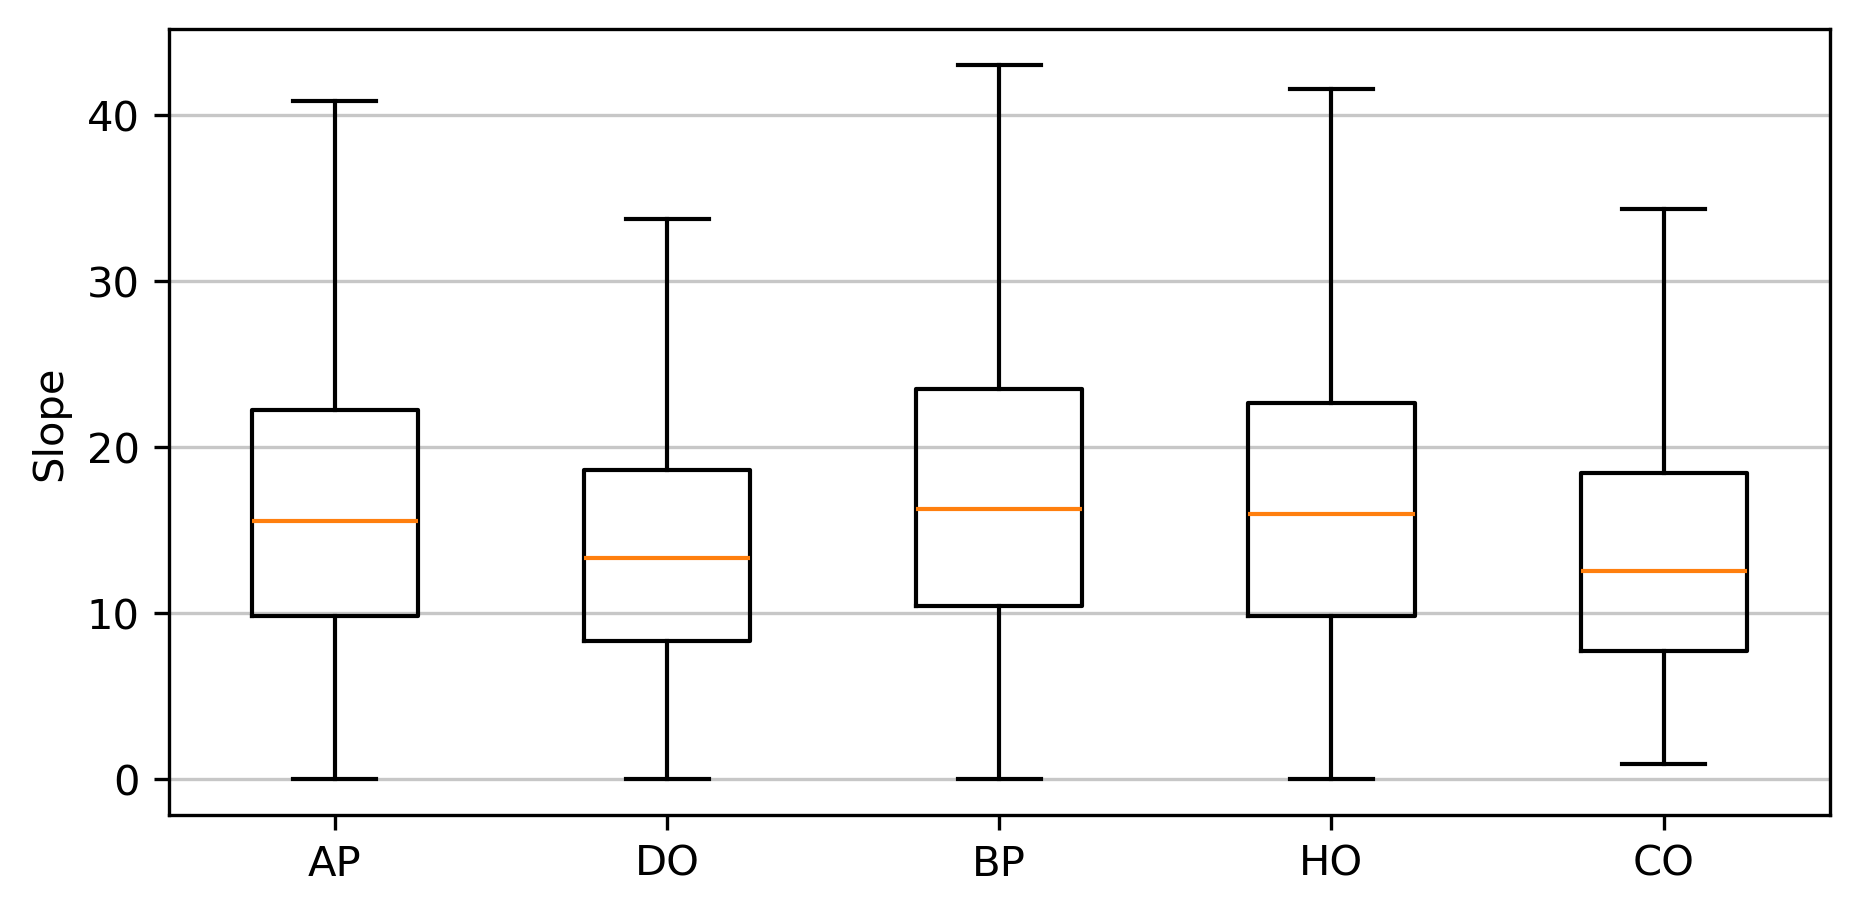

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg

# Configurar el figure canvas
fig, ax = plt.subplots(figsize=(16*conversor, 8*conversor))
canvas = FigureCanvasAgg(fig)

PH=specie.loc[(specie.Especie1=='Pinus halepensis')]
QH=specie.loc[(specie.Especie1=='Quercus humilis (Q. Pubescens)')]
PN=specie.loc[(specie.Especie1=='Pinus nigra')]
QI=specie.loc[(specie.Especie1=='Quercus ilex')]
QS=specie.loc[(specie.Especie1=='Quercus suber')]

# Preparar los datos
array_ph = np.array(list(PH[var]))
array_qh = np.array(list(QH[var]))
array_pn = np.array(list(PN[var]))
array_qi = np.array(list(QI[var]))
array_qs = np.array(list(QS[var]))
# data = [array_n,array_e,array_p]
data = [array_ph,array_qh,array_pn,array_qi,array_qs]

# Crear el gráfico de cajas
# ax.boxplot(data, labels=['N', 'E', 'P'], showfliers=False)
ax.boxplot(data, labels=['AP', 'DO','BP','HO','CO'], showfliers=False)
ax.set_ylabel('Slope')

# Optimizar el rendimiento
fig.set_dpi(300)

# Personalizar el gráfico

ax.yaxis.grid(alpha=0.7)
plt.xticks(rotation=0)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [74]:
valores = array_qh

# Calculamos la media y la desviación estándar
media = np.mean(valores)
desviacion_estandar = np.std(valores, ddof=1)  # ddof=1 para la desviación estándar muestral

# Definimos el nivel de confianza (95% en este caso)
nivel_confianza = 0.95
alfa = 1 - nivel_confianza
z_critico = stats.norm.ppf(1 - alfa/2)  # Para una distribución normal

# Calculamos el margen de error
margen_error = z_critico * desviacion_estandar / np.sqrt(len(valores))

# Calculamos el intervalo de confianza
intervalo_confianza = (media - margen_error, media + margen_error)

print("Intervalo de confianza al 95%:", intervalo_confianza)
print(margen_error)
print(media)

Intervalo de confianza al 95%: (10.260345497664073, 11.031321169002595)
0.38548783566926176
10.645833333333334


In [1]:
dfs

NameError: name 'dfs' is not defined